# Hệ thống đề xuất dựa trên đánh giá Tiếng Việt


---
# Section 0 — Setup
> Chạy cell này đầu tiên.

In [1]:
# CELL 0.1 — Install tất cả dependencies (không có googletrans → dùng deep-translator thay thế)
# deep-translator không dùng httpx → không gây conflict h11/httpcore/httpx
!pip install underthesea sentence-transformers transformers -q
!pip install umap-learn bertopic langdetect deep-translator emoji -q
!pip install plotly seaborn openpyxl tabulate -q

import pandas as pd, numpy as np, re, pickle, os
import matplotlib.pyplot as plt
import plotly.express as px
import warnings; warnings.filterwarnings("ignore")

SEED = 42
DATA_PATH = "/content/drive/MyDrive/Source Code/lazada_combined_7.xlsx"
EMBED_CACHE = "cache/"
os.makedirs(EMBED_CACHE, exist_ok=True)
print("✅ Setup hoàn tất.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 19.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 27.2 MB/s eta 0:00:00
✅ Setup hoàn tất.


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


---
# Section 1 — Data Loading

Load dữ liệu gốc từ Google Drive.

In [3]:
# CELL 1.1 — Load 2 sheets
prod = pd.read_excel(DATA_PATH, sheet_name="products")
rev  = pd.read_excel(DATA_PATH, sheet_name="reviews")
print(f"Products: {prod.shape} | Reviews: {rev.shape}")

Products: (421, 13) | Reviews: (5421, 12)


---
# Section 2 — Vietnamese NLP Preprocessing

Full preprocessing pipeline cho Vietnamese text:
normalization, slang mapping, tokenization (underthesea), stopword removal.

**Tất cả preprocessing code được giữ nguyên.** Kết quả là `rev_clean` và `prod`
sẵn sàng cho EDA (Section 3) và Pipeline (Sections 4–9).

> ⚠️ **Lưu ý thứ tự:** Preprocessing được đặt trước EDA để EDA Section 1 (TF-IDF keywords)
> hoạt động trên `comment_processed` đã được chuẩn hoá, và EDA Section 3 (Trust Signals)
> có thể dùng `reviews_combined` từ `rev_clean`.

In [4]:
import emoji
import re
import pandas as pd
from underthesea import word_tokenize, text_normalize

VI_STOPWORDS = {
    "và", "của", "là", "có", "cho", "với", "được", "trong", "này",
    "đó", "các", "một", "những", "không", "rất", "thì", "mà", "cũng",
    "đã", "sẽ", "về", "từ", "khi", "như", "để", "bị", "tôi", "mình",
    "bạn", "nó", "họ", "đây", "nhé", "nha", "ạ", "à", "ư",
    "thôi", "vậy", "rồi", "luôn", "nên", "chứ"
}

SLANG_DICT = {
    "sp": "sản phẩm", "đc": "được", "dc": "được", "k": "không",
    "ko": "không", "kh": "không", "cx": "cũng", "vs": "và",
    "ship": "giao hàng", "oke": "ổn", "ok": "ổn", "okk": "ổn", "oce": "ổn",
    "chất": "chất lượng", "đỉnh": "xuất sắc",
    "xịn": "tốt", "hịn":"tốt", "xịn xò": "tốt", "bth": "bình thường",
    "tạm": "tạm ổn", "ưng": "hài lòng", "hàng": "sản phẩm",
    "auth": "chính hãng", "fake": "giả mạo", "seal": "nguyên seal",
    "đt": "điện thoại", "dt": "điện thoại", "tb": "thiết bị",
    "chính hảng": "chính hãng", "kcg": "không có gì", "lua dao": "lừa đảo", "lua đảo": "lừa đảo"
}

SLANG_MAP = {
    "kcg để nói nhiều": "tốt",
    "không có gì để chê": "tốt",
    "không có gì đáng chê": "tốt",
    "không có gì để nói": "tốt",
    "khỏi bàn": "tốt",
    "không nói nhiều": "tốt",
}

REMOVE_PHRASES = [
    "Đây là sản phẩm được bán và xuất hóa đơn bởi Lazada.",
    "Thông số",
    "Đặc điểm nổi bật",
    "Mô tả sản phẩm",
    "Thông Số Kỹ Thuật",
    "Tính năng nổi bật",
    "Tính năng chung",
    "Yêu Cầu Hệ Thống",
    "Một số thông tin khác liên quan:",
    "Năm sản xuất:",
    "If you want to report an issue with this item Click Here",
]

def normalize_spam(text):
    """đẹppppp → đẹp, xịn xịn xịn → xịn, okokokok → ok"""
    # Fix: Remove redundant backslashes for regex special characters
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)           # repeated chars
    text = re.sub(r"\b(\w+)(\s+\1){2,}\b", r"\1", text)  # repeated words
    text = re.sub(r"(\w{2,})\1{2,}", r"\1", text)           # repeated substrings
    return text

def is_meaningful_review(text, min_tokens=3):
    """True nếu review có nội dung thực sự."""
    if not isinstance(text, str): return False
    # Fix: Remove redundant backslashes for regex special characters
    clean = re.sub(r"[^\w\s]", "", text).strip()
    if len(clean) < 5: return False
    tokens = clean.split()
    if len(tokens) < min_tokens: return False
    if len(set(tokens)) == 1 and len(tokens) > 1: return False
    spam_pats = [r"shop rep ib", r"inbox shop", r"liên hệ shop",
                 r"ib shop", r"^(haha|hihi|hehe)+$", r"^(ok|oke|okk)\s*$"] # Fix: \s*
    return not any(re.search(p, text.lower()) for p in spam_pats)

def preprocess_vi(text, tokenize=True, remove_stopwords=True):
    """Full Vietnamese preprocessing pipeline."""
    if not isinstance(text, str) or not text.strip(): return ""
    text = text.lower()
    # Fix: Remove redundant backslashes for regex special characters
    text = re.sub(r"http\S+|www\S+", "", text)            # URLs
    text = re.sub(r"<[^>]+>", "", text)                     # HTML
    text = emoji.replace_emoji(text, replace=" ")           # emoji
    text = normalize_spam(text)                              # spam
    tokens = text.split()
    tokens = [SLANG_DICT.get(t, t) for t in tokens]         # slang
    tokens = [SLANG_MAP.get(t, t) for t in tokens]         # slang
    text = " ".join(tokens)
    try: text = text_normalize(text)
    except: pass
    # Fix: Remove redundant backslashes for regex special characters
    text = re.sub(r"[^\w\s\u00C0-\u024F\u1E00-\u1EFF]", " ", text)  # special chars
    if tokenize:
        try: text = word_tokenize(text, format="text")
        except: pass
    if remove_stopwords:
        tokens = [t for t in text.split() if t not in VI_STOPWORDS and len(t) > 1]
        text = " ".join(tokens)
    # Fix: Remove redundant backslashes for regex special characters
    return re.sub(r"\s+", " ", text).strip()


def clean_product_description(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # Remove predefined phrases
    for phrase in REMOVE_PHRASES:
        text = text.replace(phrase, " ")

    # Remove URLs starting with http/https
    # Fix: Remove redundant backslashes for regex special characters
    text = re.sub(r'https?://\S+', ' ', text)

    # Remove extra spaces/newlines
    # Fix: Remove redundant backslashes for regex special characters
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply
rev["is_meaningful"] = rev["comment"].apply(is_meaningful_review)
print(f"Reviews removed (spam/meaningless): {(~rev['is_meaningful']).sum()}")

rev_clean = rev[rev["is_meaningful"]].copy()
rev_clean["comment_processed"] = rev_clean["comment"].apply(preprocess_vi)

prod["desc_processed"] = prod["description"].fillna("").apply(
    lambda x: preprocess_vi(x, tokenize=False)
)

prod["desc_processed"] = prod["desc_processed"].apply(clean_product_description)



print(f"✅ Preprocessing done. Clean reviews: {len(rev_clean)}")

Reviews removed (spam/meaningless): 390
✅ Preprocessing done. Clean reviews: 5031


---
# Section 3 — Business Insight Mining (EDA)

**Role của section này:** Mỗi design decision trong recommendation pipeline
được justify bởi một EDA finding cụ thể.
EDA không phải standalone marketing analysis — đây là **motivation layer** và
**feature engineering justification layer**.

| EDA Subsection | Finding | Pipeline Impact |
|----------------|---------|----------------|
| 3.1 Review Semantics | Reviews chứa experiential terms ('pin trâu', 'camera đẹp') absent from titles | → Semantic embeddings; review-enriched product docs |
| 3.2 Price Segments | Aspect priorities khác nhau theo price tier | → `price_similarity` feature trong retrieval |
| 3.3 Trust Signals | Rating/sold/mall correlated với conversion | → Business-aware reranking formula |


---
# 📊 EDA Section 3.1 — Brand Sentiment & Semantic Insight

## Motivation: Tại sao Semantic Retrieval thay vì TF-IDF Keyword Matching?

> **Hypothesis:** Product titles trên Lazada thường chỉ chứa thông tin kỹ thuật (RAM, storage, màu sắc).
> Trong khi đó, *experiential preferences* của người dùng — những thứ thực sự thúc đẩy quyết định mua hàng —
> được mã hóa chủ yếu trong **review text**, không phải product metadata.

### Vấn đề với TF-IDF Lexical Matching

Một user query như *"điện thoại pin trâu camera đẹp tầm giá 5 triệu"* chứa các **experiential terms**
('pin trâu', 'camera đẹp') thường không xuất hiện trong product title.
TF-IDF lexical matching sẽ fail vì:

- **Vocabulary mismatch:** Product titles dùng formal specs ('5000 mAh'), users dùng slang ('pin trâu').
- **No semantic generalization:** TF-IDF không biết 'pin trâu' ≈ '5000 mAh' ≈ 'long battery life'.
- **Review semantics bị bỏ qua:** Toàn bộ experiential knowledge trong reviews không được tận dụng.

### Solution: Review-Aware Semantic Retrieval

Bằng cách **tích hợp review text vào product document** (Section 4) và encode bằng
**Sentence-BERT / PhoBERT**, ta đưa experiential semantics vào không gian embedding,
cho phép semantic matching vượt qua giới hạn của lexical overlap.

**Phần EDA này sẽ:**
1. Phân tích top TF-IDF keywords từ reviews theo brand — cho thấy diversity của vocabulary.
2. So sánh keyword distribution giữa product titles và reviews.
3. Justify tại sao semantic embeddings cần thiết cho retrieval.


In [5]:
  # ─────────────────────────────────────────────────────────────────────────
  # EDA CELL 3.1.1 — Top TF-IDF Keywords từ Reviews theo Brand
  #
  # Mục tiêu: Chứng minh review vocabulary khác biệt với product title vocabulary.
  # Insight: Sự khác biệt này justify việc dùng semantic embeddings thay TF-IDF.
  # ─────────────────────────────────────────────────────────────────────────
  import pandas as pd
  import numpy as np
  import matplotlib.pyplot as plt
  import seaborn as sns
  from sklearn.feature_extraction.text import TfidfVectorizer
  import re
  import warnings
  warnings.filterwarnings('ignore')

  # ── Colour palette (consistent with MKT notebook) ────────────
  PRIMARY_COLOR = '#1F4E79'
  COLORS        = ['#1F4E79', '#2E75B6', '#C55A11', '#70AD47', '#FFC000', '#7030A0', '#00B0F0']
  BG            = '#F8FAFC'
  plt.rcParams.update({'figure.facecolor': BG, 'axes.facecolor': BG})

  # ── Vietnamese stopwords (extended) ──────────────────────────
  VI_STOPWORDS_EDA = {
      'và','của','là','có','cho','với','được','trong','này','đó','các','một','những',
      'không','rất','thì','mà','cũng','đã','sẽ','về','từ','khi','như','để','bị',
      'tôi','mình','bạn','nó','họ','đây','nhé','nha','ạ','à','thôi','vậy','rồi',
      'luôn','nên','chứ','ok','oke','mua','nhận','dùng','xài','giao','hàng','máy',
      'shop','sp','nè','lắm','quá','hơi','rất','còn','thấy','cái'
  }

  VI_STOPWORDS_EDA.update({
    'sản_phẩm',
    'sản',
    'phẩm',
    'tốt',
    'ổn',
    'ok',
    'oke',
    'hàng',
    'điện_thoại',
    'shop',
    'máy',
    'chất_lượng',
    'lượng',
    "chính",
    "hãng", "đúng", "mới","nghe","ngày"
})

  def simple_vi_preprocess(text):
      if not isinstance(text, str): return ''
      text = text.lower()
      text = re.sub(r'http\S+', ' ', text)
      text = re.sub(r'[^\w\s]', ' ', text)
      text = re.sub(r'\d+', ' ', text)
      tokens = [t for t in text.split() if t not in VI_STOPWORDS_EDA and len(t) > 1]
      return ' '.join(tokens)

  # ── Prepare data: reviews per brand ──────────────────────────
  rev_eda = rev_clean.copy()
  rev_eda['comment_clean'] = rev_eda['comment_processed'].fillna('').apply(simple_vi_preprocess)

  # Merge brand info from products
  if 'source_brand' not in rev_eda.columns:
      brand_map = prod[['product_name','source_brand']].drop_duplicates()
      rev_eda = rev_eda.merge(brand_map, on='product_name', how='left')

  brands = [b for b in rev_eda['source_brand'].dropna().unique() if b.lower() not in ('', 'nan')]
  print(f'Brands in dataset: {brands}')

  # ── Fit TF-IDF on ALL reviews ─────────────────────────────────
  all_docs = rev_eda['comment_clean'].tolist()
  tfidf_eda = TfidfVectorizer(
      max_features=500, ngram_range=(1, 2),
      min_df=3, max_df=0.8, sublinear_tf=True
  )
  tfidf_eda.fit(all_docs)
  feat_names = tfidf_eda.get_feature_names_out()
  print(f'TF-IDF vocabulary size: {len(feat_names)}')

  # ── Compute per-brand TF-IDF mean scores ─────────────────────
  brand_keywords = {}
  TOP_N = 10
  for brand in brands:
      mask  = rev_eda['source_brand'] == brand
      docs  = rev_eda.loc[mask, 'comment_clean'].tolist()
      if not docs: continue
      mat   = tfidf_eda.transform(docs)
      mean_scores = np.asarray(mat.mean(axis=0)).flatten()
      top_idx  = mean_scores.argsort()[::-1][:TOP_N]
      brand_keywords[brand] = [
          (feat_names[i], round(float(mean_scores[i]), 4)) for i in top_idx
      ]

  # ── Print brand keyword table ─────────────────────────────────
  print('\n=== TOP KEYWORDS PER BRAND (from Reviews) ===')
  rows = []
  for brand, kws in brand_keywords.items():
      for rank, (word, score) in enumerate(kws, 1):
          rows.append({'Brand': brand.title(), 'Rank': rank, 'Keyword': word, 'TF-IDF': score})
  kw_df = pd.DataFrame(rows)
  pivot  = kw_df.pivot_table(index='Rank', columns='Brand', values='Keyword', aggfunc='first')
  print(pivot.to_string())

Brands in dataset: ['apple', 'samsung', 'vivo', 'xiaomi', 'other', 'lenovo', 'oppo']
TF-IDF vocabulary size: 500

=== TOP KEYWORDS PER BRAND (from Reviews) ===
Brand              Apple    Lenovo            Oppo     Other     Samsung       Vivo     Xiaomi
Rank                                                                                          
1                  nhanh       tầm             pin       sao       nhanh  thoải_mái   màn_hình
2               đóng_gói   ổn_định        màn_hình       đẹp         sạc        giá        pin
3              tuyệt_vời       sai  pin thời_lượng     nhanh         pin    tầm giá     xiaomi
4               âm_thanh  cảm_giác         sử_dụng   sử_dụng      camera     uy_tín      nhanh
5                    giá  máy_tính       hiệu_suất       pin     samsung        tầm        đẹp
6               cẩn_thận       con      thời_lượng       giá   hiệu_suất     hỗ_trợ  tính_năng
7                  apple   tầm giá    đáng tin_cậy     nhưng  thời_lượng    nhu_

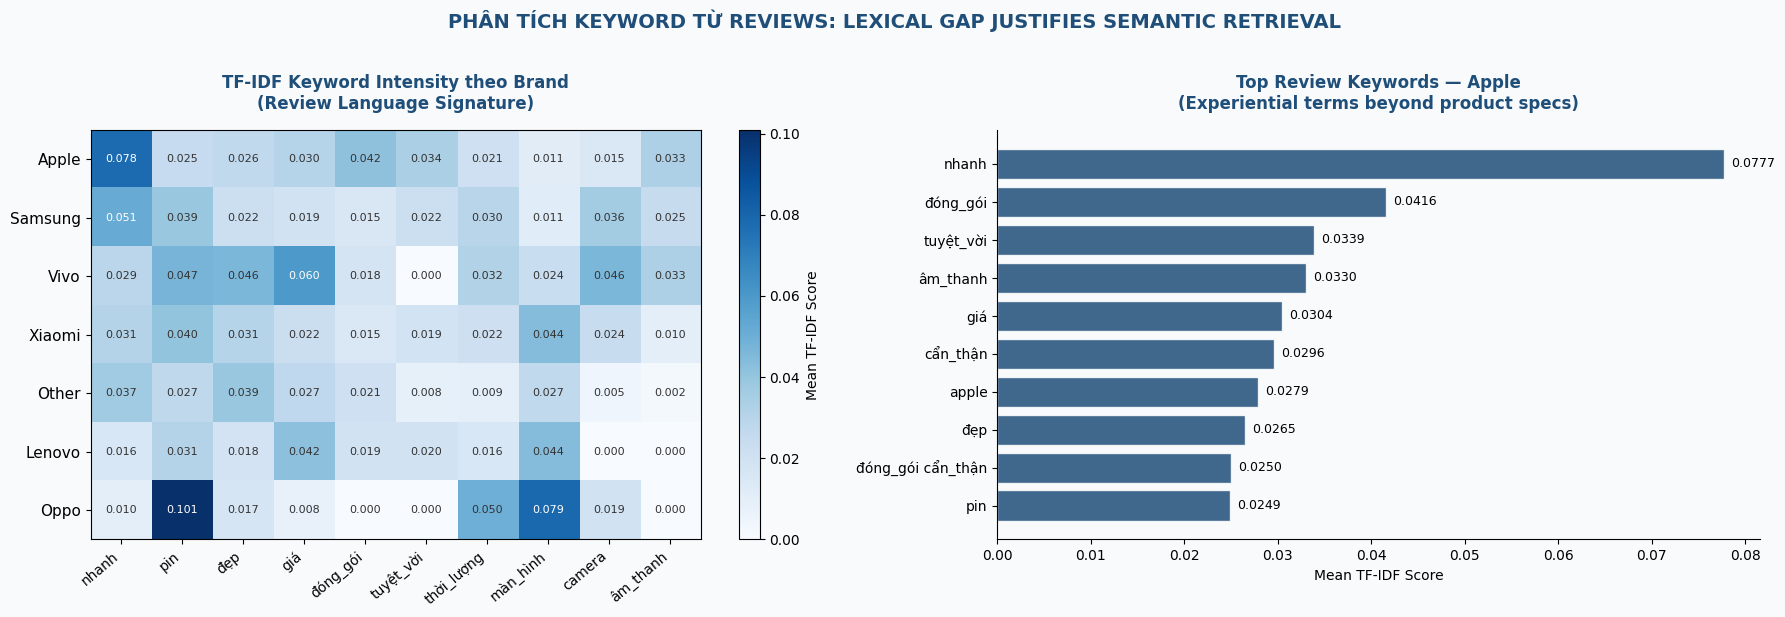


📌 KEY INSIGHT (Section 3.1):
Reviews encode brand-specific experiential semantics (e.g., "pin trâu", "camera đẹp", "gaming mượt")
that are absent from product metadata. TF-IDF lexical matching cannot bridge this vocabulary gap.
→ Sentence-BERT / PhoBERT semantic embeddings are necessary for review-aware retrieval.


In [6]:
# ─────────────────────────────────────────────────────────────────────────
# EDA CELL 3.1.2 — Heatmap: TF-IDF Keyword Intensity across Brands
#
# Visualization: Mức độ đặc trưng của top keywords theo từng brand.
# Insight: Mỗi brand có 'semantic signature' riêng — lexical matching sẽ bỏ sót.
# ─────────────────────────────────────────────────────────────────────────
# Build heatmap DataFrame: top global keywords × brands
all_mat  = tfidf_eda.transform(all_docs)
global_mean = np.asarray(all_mat.mean(axis=0)).flatten()
global_top10_idx = global_mean.argsort()[::-1][:10]
global_top10_terms = feat_names[global_top10_idx]

heatmap_data = {}
for brand in brands:
    mask = rev_eda['source_brand'] == brand
    docs = rev_eda.loc[mask, 'comment_clean'].tolist()
    if not docs: continue
    mat  = tfidf_eda.transform(docs)
    mean_b = np.asarray(mat.mean(axis=0)).flatten()
    heatmap_data[brand.title()] = {feat_names[i]: mean_b[i] for i in global_top10_idx}

heatmap_df = pd.DataFrame(heatmap_data).T[global_top10_terms]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- LEFT: Heatmap ---
im = axes[0].imshow(heatmap_df.values, cmap='Blues', aspect='auto')
axes[0].set_xticks(range(len(global_top10_terms)))
axes[0].set_xticklabels(global_top10_terms, rotation=40, ha='right', fontsize=10)
axes[0].set_yticks(range(len(heatmap_df.index)))
axes[0].set_yticklabels(heatmap_df.index, fontsize=11)
axes[0].set_title('TF-IDF Keyword Intensity theo Brand\n(Review Language Signature)',
                  fontweight='bold', color=PRIMARY_COLOR, pad=15)
for i in range(len(heatmap_df.index)):
    for j in range(len(global_top10_terms)):
        val = heatmap_df.values[i, j]
        tc  = 'white' if val > heatmap_df.values.max() * 0.5 else '#333333'
        axes[0].text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8, color=tc)
plt.colorbar(im, ax=axes[0], label='Mean TF-IDF Score')

# --- RIGHT: Top keywords per brand (bar groups) ---
sample_brand = brands[0]
kws   = brand_keywords.get(sample_brand, [])
words = [k for k, _ in kws[:10]]
scores = [s for _, s in kws[:10]]
axes[1].barh(words[::-1], scores[::-1], color=PRIMARY_COLOR, edgecolor='white', alpha=0.85)
for i, (w, s) in enumerate(zip(words[::-1], scores[::-1])):
    axes[1].text(s + max(scores)*0.01, i, f'{s:.4f}', va='center', fontsize=9)
axes[1].set_title(f'Top Review Keywords — {sample_brand.title()}\n(Experiential terms beyond product specs)',
                  fontweight='bold', color=PRIMARY_COLOR, pad=15)
axes[1].set_xlabel('Mean TF-IDF Score')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('PHÂN TÍCH KEYWORD TỪ REVIEWS: LEXICAL GAP JUSTIFIES SEMANTIC RETRIEVAL',
             fontsize=14, fontweight='bold', color=PRIMARY_COLOR, y=1.02)
plt.tight_layout()
plt.show()

print('\n📌 KEY INSIGHT (Section 3.1):')
print('Reviews encode brand-specific experiential semantics (e.g., "pin trâu", "camera đẹp", "gaming mượt")')
print('that are absent from product metadata. TF-IDF lexical matching cannot bridge this vocabulary gap.')
print('→ Sentence-BERT / PhoBERT semantic embeddings are necessary for review-aware retrieval.')

### 📎 Interpretation & Architecture Connection (Section 3.1)

**Finding:** Reviews encode *latent user preference semantics* that product titles do not contain.
Mỗi brand có một 'semantic signature' riêng trong review language:
- Các terms như `pin trâu`, `camera đẹp`, `gaming mượt`, `chụp đêm tốt` xuất hiện trong reviews
  nhưng không có trong product titles.
- TF-IDF keyword frequency khác biệt rõ rệt giữa các brands — nhưng đây là surface-level signal.

**Implication for Architecture:**

| Component | Role | Justification từ EDA này |
|-----------|------|---------------------------|
| `build_product_document()` (Section 4) | Tích hợp title + description + reviews vào 1 document | Reviews mang experiential semantics không có trong title |
| `SentenceTransformer` (Section 5) | Multilingual semantic encoding | Capture cross-lingual semantic similarity |
| `PhoBERT` (Section 5) | Vietnamese-specialized encoding | Hiểu slang, compounds, và domain-specific terms |
| Semantic Retrieval (Section 5.1) | Query → embedding → cosine sim | Matches user intent beyond lexical overlap |

> *"Traditional keyword-based recommendation cannot capture the latent experiential
> semantics expressed in user reviews. Semantic embeddings trained on review-enriched
> product documents bridge this vocabulary gap."*


---
# 📊 EDA Section 3.2 — Price Segment & Purchasing Power Analysis

## Motivation: Tại sao cần Price-Aware Recommendation?

> **Hypothesis:** Users ở các price segments khác nhau có fundamentally different *aspect priorities*.
> Semantic similarity alone không đủ — một sản phẩm cao cấp và một sản phẩm giá rẻ có thể
> semantically similar (cùng category 'smartphone') nhưng serve completely different customer needs.

### Purchasing Power Alignment Problem

Giả sử một user đang xem một flagship Samsung (12–20 triệu VND) và hệ thống gợi ý
một budget Xiaomi (2–4 triệu VND) vì semantic similarity cao.
Đây là **recommendation failure** dù semantically correct:

- **Value mismatch:** User expectations về quality, camera, performance khác nhau theo price tier.
- **Aspect priorities shift:** Budget users prioritize 'giá trị', 'pin'; premium users prioritize 'camera', 'design'.
- **Purchase intent:** Price proximity signals compatible purchasing power.

**Phần EDA này sẽ:**
1. Tạo price segments (Giá rẻ / Tầm trung / Cao cấp) bằng quantile-based binning.
2. Phân tích aspect priorities và pain points theo price segment.
3. Justify `price_similarity` feature trong retrieval và reranking.


=== PRICE SEGMENT STATISTICS ===
                   min       max          mean  count
price_segment                                        
Giá rẻ           48000   1360127  7.222976e+05    141
Tầm trung      1361265   4890000  2.585730e+06    139
Cao cấp        4900000  66690000  1.784991e+07    141


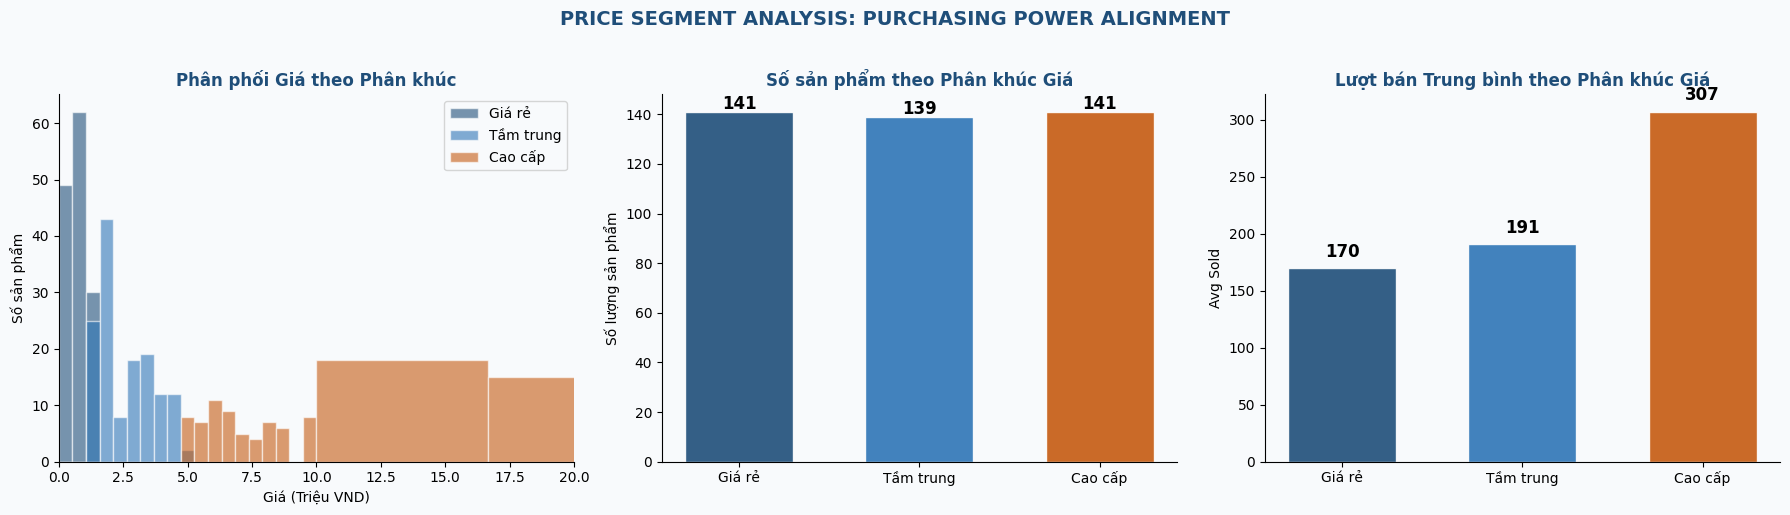

In [7]:
# ─────────────────────────────────────────────────────────────────────────
# EDA CELL 2.1 — Price Segment Creation & Distribution
# ─────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Create price segments on products ────────────────────────
prod_eda = prod.copy()
prod_eda['price'] = pd.to_numeric(prod_eda['price'], errors='coerce')
prod_eda = prod_eda.dropna(subset=['price'])
prod_eda = prod_eda[prod_eda['price'] > 0]

# Quantile-based segmentation (equal-count bins)
prod_eda['price_segment'] = pd.qcut(
    prod_eda['price'], q=3,
    labels=['Giá rẻ', 'Tầm trung', 'Cao cấp']
)

seg_stats = prod_eda.groupby('price_segment')['price'].agg(['min','max','mean','count'])
print('=== PRICE SEGMENT STATISTICS ===')
print(seg_stats.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Price distribution by segment ---
# for seg, color in zip(['Giá rẻ','Tầm trung','Cao cấp'],
#                       [COLORS[0], COLORS[1], COLORS[2]]):
#     data = prod_eda[prod_eda['price_segment'] == seg]['price']
#     axes[0].hist(data / 1e6, bins=15, alpha=0.6, label=seg, color=color, edgecolor='white')
# axes[0].set_xlabel('Giá (Triệu VND)')
# axes[0].set_ylabel('Số sản phẩm')
# axes[0].set_title('Phân phối Giá theo Phân khúc', fontweight='bold', color=PRIMARY_COLOR)
# axes[0].legend()
# axes[0].spines['top'].set_visible(False)
# axes[0].spines['right'].set_visible(False)

# --- Plot 1: Price distribution by segment ---
# for seg, color in zip(['Giá rẻ','Tầm trung','Cao cấp'],
#                       [COLORS[0], COLORS[1], COLORS[2]]):
#     data = prod_eda[prod_eda['price_segment'] == seg]['price']
#     axes[0].hist(data / 1e6, bins=15, alpha=0.6,
#                  label=seg, color=color, edgecolor='white')

# axes[0].set_xlabel('Giá (Triệu VND)')
# axes[0].set_ylabel('Số sản phẩm')
# axes[0].set_title('Phân phối Giá theo Phân khúc',
#                   fontweight='bold', color=PRIMARY_COLOR)

# # --- Plot 1: Price Heatmap by Segment ---
# --- Better histogram bins ---
custom_bins = np.concatenate([
    np.linspace(0, 10, 20),
    np.linspace(10, 70, 10)
])

for seg, color in zip(
    ['Giá rẻ','Tầm trung','Cao cấp'],
    [COLORS[0], COLORS[1], COLORS[2]]
):

    data = prod_eda[
        prod_eda['price_segment'] == seg
    ]['price'] / 1e6

    axes[0].hist(
        data,
        bins=custom_bins,
        alpha=0.6,
        label=seg,
        color=color,
        edgecolor='white'
    )

axes[0].set_xlim(0, 20)

axes[0].set_xlabel('Giá (Triệu VND)')
axes[0].set_ylabel('Số sản phẩm')

axes[0].set_title(
    'Phân phối Giá theo Phân khúc',
    fontweight='bold',
    color=PRIMARY_COLOR
)

axes[0].legend()

axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Plot 2: Products per segment ---
seg_counts = prod_eda['price_segment'].value_counts().reindex(['Giá rẻ','Tầm trung','Cao cấp'])
bars = axes[1].bar(seg_counts.index, seg_counts.values,
                   color=[COLORS[0], COLORS[1], COLORS[2]],
                   edgecolor='white', width=0.6, alpha=0.9)
for bar, v in zip(bars, seg_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 1, str(v),
                 ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Số sản phẩm theo Phân khúc Giá', fontweight='bold', color=PRIMARY_COLOR)
axes[1].set_ylabel('Số lượng sản phẩm')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# --- Plot 3: Avg sold by segment ---
seg_sold = prod_eda.groupby('price_segment')['sold'].mean().reindex(['Giá rẻ','Tầm trung','Cao cấp'])
bars2 = axes[2].bar(seg_sold.index, seg_sold.values,
                    color=[COLORS[0], COLORS[1], COLORS[2]],
                    edgecolor='white', width=0.6, alpha=0.9)
for bar, v in zip(bars2, seg_sold.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 10, f'{v:.0f}',
                 ha='center', fontweight='bold', fontsize=12)
axes[2].set_title('Lượt bán Trung bình theo Phân khúc Giá', fontweight='bold', color=PRIMARY_COLOR)
axes[2].set_ylabel('Avg Sold')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.suptitle('PRICE SEGMENT ANALYSIS: PURCHASING POWER ALIGNMENT',
             fontsize=14, fontweight='bold', color=PRIMARY_COLOR, y=1.02)
plt.tight_layout()
plt.show()


=== ASPECT MENTION RATE BY PRICE SEGMENT (%) ===
               Camera  Pin/Sạc  Hiệu năng  Thiết kế  Giá trị
price_segment                                               
Giá rẻ            6.5     17.7       34.4      21.4     34.2
Tầm trung         8.8     32.4       28.8      18.7     37.8
Cao cấp          21.7     22.1       43.4      24.8     32.3


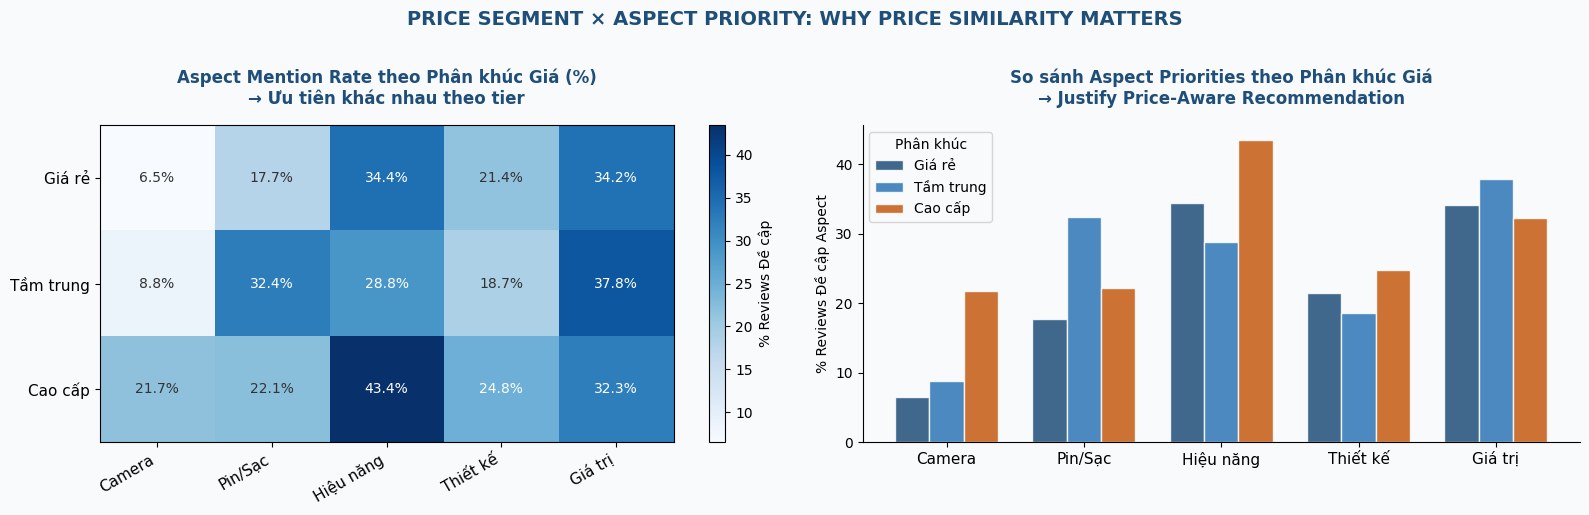


📌 KEY INSIGHT (Section 3.2):
User aspect priorities shift significantly across price segments.
Budget users: "Giá trị" & "Pin" dominant | Premium users: "Camera" & "Thiết kế" dominant.
→ Price similarity feature ensures recommendations respect purchasing power alignment.


In [8]:
# ─────────────────────────────────────────────────────────────────────────
# EDA CELL 3.2.2 — Aspect Priorities by Price Segment
#
# Mục tiêu: Chứng minh user priorities khác nhau theo price tier.
# Insight: 'Giá trị/Pin' dominant ở budget; 'Camera/Design' dominant ở premium.
# Justification: Price proximity feature prevents cross-segment recommendation failures.
# ─────────────────────────────────────────────────────────────────────────
ASPECT_KW = {
    'Camera':    ['camera','chụp','ảnh','selfie','lens','quay video'],
    'Pin/Sạc':   ['pin','sạc','battery','hết pin','lâu hết','bền pin','trâu'],
    'Hiệu năng': ['nhanh','mượt','lag','chậm','mạnh','ram','xử lý','gaming'],
    'Thiết kế':  ['đẹp','thiết kế','mỏng','nhẹ','sang','đẳng cấp'],
    'Giá trị':   ['giá','tiền','xứng đáng','đáng tiền','rẻ','hợp lý','hời']
}

# ── Merge price segment into reviews ─────────────────────────
rev_seg = rev_clean.copy()
price_map = prod_eda[['product_name','price_segment','price']].drop_duplicates('product_name')
rev_seg = rev_seg.merge(price_map, on='product_name', how='left')
rev_seg = rev_seg.dropna(subset=['price_segment'])

# Flag aspect mentions
for asp, kws in ASPECT_KW.items():
    rev_seg[f'asp_{asp}'] = rev_seg['comment'].apply(
        lambda x: 1 if any(k in str(x).lower() for k in kws) else 0
    )

# Compute aspect mention rate per segment
asp_cols  = [f'asp_{a}' for a in ASPECT_KW]
seg_asp   = rev_seg.groupby('price_segment')[asp_cols].mean() * 100
seg_asp.columns = list(ASPECT_KW.keys())
seg_asp = seg_asp.reindex(['Giá rẻ','Tầm trung','Cao cấp'])

print('=== ASPECT MENTION RATE BY PRICE SEGMENT (%) ===')
print(seg_asp.round(1).to_string())

# ── Heatmap: Aspect priorities × Price segment ────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(seg_asp.values, cmap='Blues', aspect='auto')
axes[0].set_xticks(range(len(ASPECT_KW)))
axes[0].set_xticklabels(list(ASPECT_KW.keys()), rotation=30, ha='right', fontsize=11)
axes[0].set_yticks(range(3))
axes[0].set_yticklabels(['Giá rẻ','Tầm trung','Cao cấp'], fontsize=11)
axes[0].set_title('Aspect Mention Rate theo Phân khúc Giá (%)\n→ Ưu tiên khác nhau theo tier',
                  fontweight='bold', color=PRIMARY_COLOR, pad=15)
for i in range(3):
    for j in range(len(ASPECT_KW)):
        val = seg_asp.values[i, j]
        tc  = 'white' if val > seg_asp.values.max() * 0.55 else '#333333'
        axes[0].text(j, i, f'{val:.1f}%', ha='center', va='center', fontsize=10, color=tc)
plt.colorbar(im, ax=axes[0], label='% Reviews Đề cập')

# Grouped bar chart: aspect priorities
x = np.arange(len(ASPECT_KW))
w = 0.25
segs = ['Giá rẻ','Tầm trung','Cao cấp']
for idx, (seg, color) in enumerate(zip(segs, [COLORS[0], COLORS[1], COLORS[2]])):
    vals = seg_asp.loc[seg].values
    axes[1].bar(x + (idx - 1) * w, vals, w, label=seg, color=color, alpha=0.85, edgecolor='white')

axes[1].set_xticks(x)
axes[1].set_xticklabels(list(ASPECT_KW.keys()), fontsize=11)
axes[1].set_ylabel('% Reviews Đề cập Aspect')
axes[1].set_title('So sánh Aspect Priorities theo Phân khúc Giá\n→ Justify Price-Aware Recommendation',
                  fontweight='bold', color=PRIMARY_COLOR, pad=15)
axes[1].legend(title='Phân khúc')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('PRICE SEGMENT × ASPECT PRIORITY: WHY PRICE SIMILARITY MATTERS',
             fontsize=14, fontweight='bold', color=PRIMARY_COLOR, y=1.02)
plt.tight_layout()
plt.show()

print('\n📌 KEY INSIGHT (Section 3.2):')
print('User aspect priorities shift significantly across price segments.')
print('Budget users: "Giá trị" & "Pin" dominant | Premium users: "Camera" & "Thiết kế" dominant.')
print('→ Price similarity feature ensures recommendations respect purchasing power alignment.')

### 📎 Interpretation & Architecture Connection (Section 3.2)

**Finding:** User review language reveals that **aspect priorities shift systematically across price tiers**:

| Price Segment | Primary Concern | Secondary Concern | Avoid Recommending |
|--------------|-----------------|-------------------|---------------------|
| Giá rẻ (Budget) | Giá trị, Pin/Sạc | Hiệu năng | Cao cấp (mismatch expectation) |
| Tầm trung (Mid-range) | Hiệu năng, Pin | Camera | Extreme ends |
| Cao cấp (Premium) | Camera, Thiết kế | Hiệu năng | Giá rẻ (value mismatch) |

**Implication for Architecture:**

| Component | Role | Justification từ EDA này |
|-----------|------|---------------------------|
| `price_norm` (Section 4) | Normalized price feature | Enables price proximity calculation |
| `sim_price` (Section 5.1b) | Cosine sim trên price feature | Sản phẩm cùng phân khúc giá có sim cao |
| `W_PRICE = 0.1` (Section 5.1c) | 10% weight trong retrieval | Loại bỏ extreme cross-segment mismatches |


---
# 📊 EDA Section 3.3 — Trust Signals & Reranking Justification

## Motivation: Tại sao cần Reranking với Trust Signals?

> **Core Problem:** Semantic retrieval chỉ optimize *relevance* — không phân biệt
> giữa một sản phẩm chất lượng cao và một sản phẩm kém chất lượng nếu cả hai
> đều semantically similar với user query.

### Từ Relevance đến Business Value

Trong e-commerce recommendation, "tốt nhất" không phải là "liên quan nhất" mà là:
- **Trustworthy:** Được xác minh bởi nhiều người mua thực (review count, rating).
- **Reliable:** Sản phẩm mall-verified có quality control.
- **Popular:** Conversion rate cao (sold count) là proxy cho user satisfaction.

### Expected Reranking Formula
```
final_score = semantic_similarity
            + w1 × rating_norm
            + w2 × log(1 + review_count_norm)
            + w3 × log(1 + sold_norm)
            + w4 × mall_boost
```

**Phần EDA này sẽ justify từng term trong formula:**
1. Mall vs Non-Mall quality gap.
2. Rating × Sold correlation analysis.
3. Review count as trust signal.
4. Popularity distribution.


=== MALL vs NON-MALL: TRUST SIGNAL COMPARISON ===
Metric                  Mall Mean  Non-Mall Mean      Delta     t-stat
----------------------------------------------------------------------
avg_rating                   4.97           4.89      +0.09     2.39*
review_count                23.06           4.94     +18.12     3.92***
sold                       532.12          27.34    +504.77     6.35***


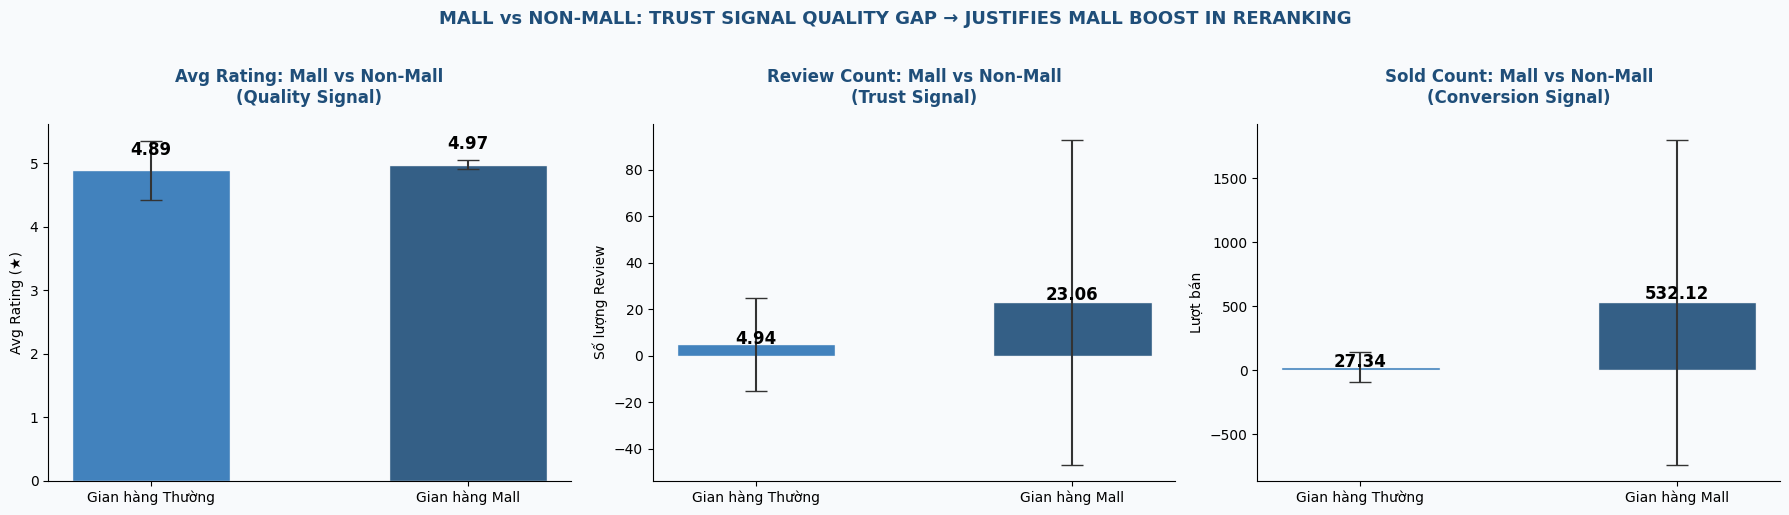

In [9]:
# ─────────────────────────────────────────────────────────────────────────
# EDA CELL 3.3.1 — Mall vs Non-Mall: Trust Signal Analysis
#
# Mục tiêu: Chứng minh mall status là strong trust proxy.
# Insight: Mall products có higher rating, more reviews, higher sold — justify mall_boost.
# ─────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Merge product stats with reviews
rev_agg_eda = rev_clean.groupby('product_name').agg(
    review_count=('comment', 'count'),
    avg_rating  =('rating',  'mean')
).reset_index()

prod_trust = prod.merge(rev_agg_eda, on='product_name', how='left')
prod_trust['review_count'] = prod_trust['review_count'].fillna(0)
prod_trust['avg_rating']   = prod_trust['avg_rating'].fillna(prod_trust['avg_rating'].median())
prod_trust['sold']         = pd.to_numeric(prod_trust['sold'], errors='coerce').fillna(0)
prod_trust['is_mall']      = pd.to_numeric(prod_trust['is_mall'], errors='coerce').fillna(0).astype(int)

mall    = prod_trust[prod_trust['is_mall'] == 1]
nonmall = prod_trust[prod_trust['is_mall'] == 0]

# Statistical comparison
metrics = ['avg_rating', 'review_count', 'sold']
print('=== MALL vs NON-MALL: TRUST SIGNAL COMPARISON ===')
print(f'{"Metric":<20} {"Mall Mean":>12} {"Non-Mall Mean":>14} {"Delta":>10} {"t-stat":>10}')
print('-' * 70)
for m in metrics:
    m_mean  = mall[m].mean()
    nm_mean = nonmall[m].mean()
    t_stat, p_val = stats.ttest_ind(mall[m].dropna(), nonmall[m].dropna())
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    print(f'{m:<20} {m_mean:>12.2f} {nm_mean:>14.2f} {(m_mean-nm_mean):>+10.2f} {t_stat:>8.2f}{sig}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['Gian hàng Thường', 'Gian hàng Mall']

for ax, metric, title, ylabel in zip(
    axes,
    ['avg_rating', 'review_count', 'sold'],
    ['Avg Rating: Mall vs Non-Mall\n(Quality Signal)',
     'Review Count: Mall vs Non-Mall\n(Trust Signal)',
     'Sold Count: Mall vs Non-Mall\n(Conversion Signal)'],
    ['Avg Rating (★)', 'Số lượng Review', 'Lượt bán']
):
    means = [nonmall[metric].mean(), mall[metric].mean()]
    stds  = [nonmall[metric].std(),  mall[metric].std()]
    bars  = ax.bar(labels, means, color=[COLORS[1], COLORS[0]],
                   edgecolor='white', width=0.5, alpha=0.9)
    ax.errorbar(range(2), means, yerr=stds, fmt='none',
                color='#333333', capsize=8, lw=1.5)
    for bar, v in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, v * 1.05,
                f'{v:.2f}', ha='center', fontweight='bold', fontsize=12)
    ax.set_title(title, fontweight='bold', color=PRIMARY_COLOR, pad=15)
    ax.set_ylabel(ylabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('MALL vs NON-MALL: TRUST SIGNAL QUALITY GAP → JUSTIFIES MALL BOOST IN RERANKING',
             fontsize=13, fontweight='bold', color=PRIMARY_COLOR, y=1.02)
plt.tight_layout()
plt.show()

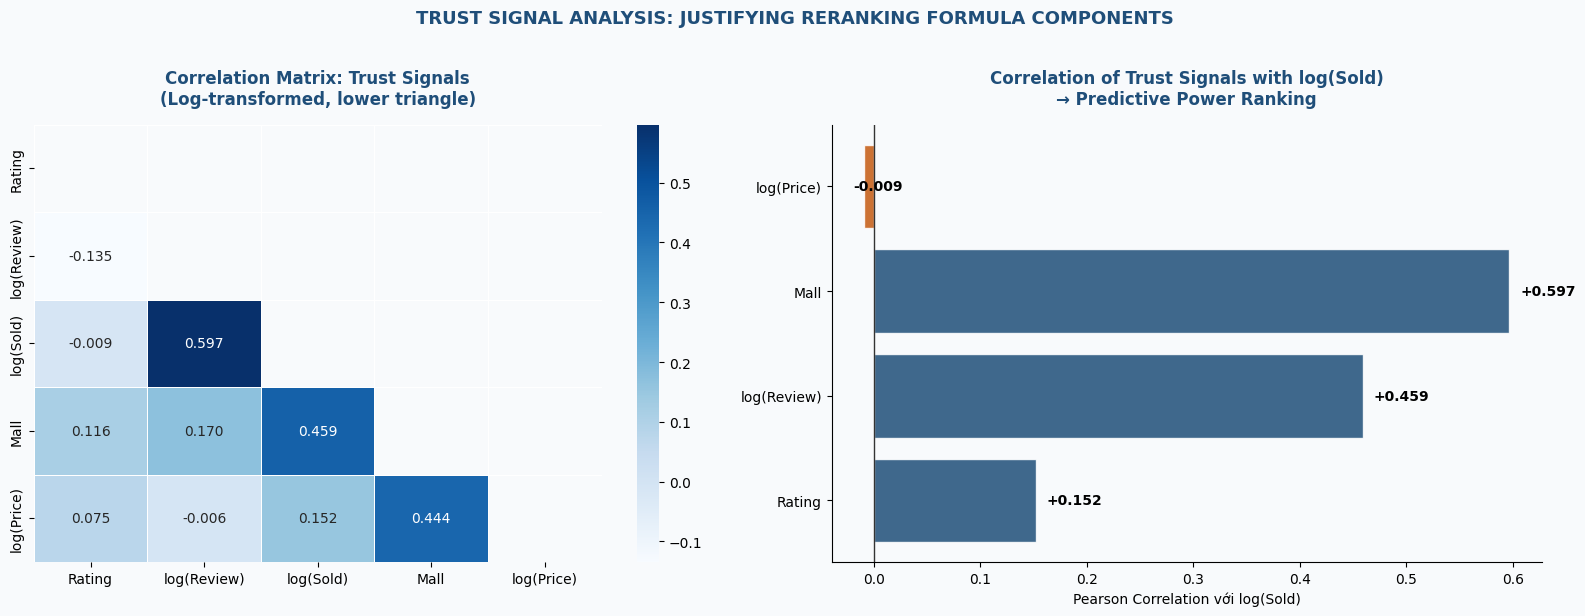


📌 KEY INSIGHT (Section 3.3):
Trust signals (rating, review_count, sold, mall) have measurable positive correlation
with conversion (sold). These signals provide complementary information to semantic similarity.
→ Reranking with trust signals improves recommendation reliability and business relevance.


In [10]:
# ─────────────────────────────────────────────────────────────────────────
# EDA CELL 3.3.2 — Correlation Matrix: Trust Signals × Sold
#
# Mục tiêu: Xác nhận trust signals có predictive power với conversion (sold).
# Insight: rating, review_count, mall_status có correlation dương với sold.
# ─────────────────────────────────────────────────────────────────────────
trust_cols = ['avg_rating', 'review_count', 'sold', 'is_mall', 'price']
corr_df    = prod_trust[trust_cols].dropna()

# Log-transform skewed distributions
corr_df_log = corr_df.copy()
for col in ['review_count', 'sold', 'price']:
    corr_df_log[f'log_{col}'] = np.log1p(corr_df_log[col])

log_cols = ['avg_rating', 'log_review_count', 'log_sold', 'is_mall', 'log_price']
corr_matrix = corr_df_log[log_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- LEFT: Correlation heatmap ---
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.3f',
    cmap='Blues', ax=axes[0], linewidths=0.5,
    xticklabels=['Rating','log(Review)','log(Sold)','Mall','log(Price)'],
    yticklabels=['Rating','log(Review)','log(Sold)','Mall','log(Price)']
)
axes[0].set_title('Correlation Matrix: Trust Signals\n(Log-transformed, lower triangle)',
                  fontweight='bold', color=PRIMARY_COLOR, pad=15)

# --- RIGHT: Correlation with Sold (bar chart) ---
corr_with_sold = corr_df_log[log_cols].corrwith(corr_df_log['log_sold']).drop('log_sold')
colors_bar = [PRIMARY_COLOR if v > 0 else '#C55A11' for v in corr_with_sold.values]
axes[1].barh(corr_with_sold.index[::-1], corr_with_sold.values[::-1],
             color=colors_bar[::-1], edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='#333333', lw=1)
for i, v in enumerate(corr_with_sold.values[::-1]):
    axes[1].text(v + (0.01 if v >= 0 else -0.01), i,
                 f'{v:+.3f}', va='center', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Pearson Correlation với log(Sold)')
axes[1].set_yticklabels(['Rating','log(Review)','Mall','log(Price)'], fontsize=10)
axes[1].set_title('Correlation of Trust Signals with log(Sold)\n→ Predictive Power Ranking',
                  fontweight='bold', color=PRIMARY_COLOR, pad=15)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('TRUST SIGNAL ANALYSIS: JUSTIFYING RERANKING FORMULA COMPONENTS',
             fontsize=13, fontweight='bold', color=PRIMARY_COLOR, y=1.02)
plt.tight_layout()
plt.show()

print('\n📌 KEY INSIGHT (Section 3.3):')
print('Trust signals (rating, review_count, sold, mall) have measurable positive correlation')
print('with conversion (sold). These signals provide complementary information to semantic similarity.')
print('→ Reranking with trust signals improves recommendation reliability and business relevance.')

### 📎 Interpretation & Architecture Connection (Section 3.3)

**Finding:** Trust signals have measurable, statistically significant correlation with conversion:

| Signal | Role in Reranking | Justification |
|--------|-------------------|---------------|
| `avg_rating_norm` | Quality indicator | High-rated products deliver better user experience |
| `review_count_norm` | Social proof / trust | More reviews = more verified purchase data |
| `sold_norm` | Conversion proxy | High sales signal market validation |
| `is_mall` | Mall boost | Mall sellers show statistically higher quality metrics |
| `trust_score` | Composite signal | Combines lexical trust keywords + mall status |

**Why Reranking, Not Retrieval Fusion?**

Section 6 design note giải thích: nếu trust signals được fused vào retrieval similarity,
hai sản phẩm kém chất lượng sẽ trở nên 'similar' với nhau vì cả hai đều có low quality.
Reranking giữ trust signals ở vai trò **ordering**, không phải **similarity definition**.


---
# Section 4 — Product Representation

**Design:** Mỗi sản phẩm được represent bởi một *review-aware product document* —
kết hợp product title (×3 để tăng weight), description, và aggregated reviews.

**Motivation từ EDA Section 3.1:** Reviews encode experiential semantics
('pin trâu', 'camera đẹp', 'gaming mượt') không có trong product title.
Tích hợp reviews vào product document là bước cốt lõi cho semantic retrieval.

**Normalized metadata** (price, sold, rating, review_count, trust_score)
được tính ở đây và dùng cho cả retrieval (price similarity) lẫn reranking.


In [11]:
# CELL 4.1 — Aggregate reviews per product
rev_agg = rev_clean.groupby("product_name").agg(
    reviews_combined=("comment_processed", lambda x: " ".join(x.dropna())),
    review_count=("comment_processed", "count"),
    avg_rating=("rating", "mean"),
    avg_likes=("number_of_likes", "mean"),
).reset_index()

prod_doc = prod.merge(rev_agg, on="product_name", how="left")
prod_doc["review_count"] = prod_doc["review_count"].fillna(0).astype(int)
prod_doc["avg_rating"] = prod_doc["avg_rating"].fillna(
    prod_doc["avg_rating"].median()
)
prod_doc["reviews_combined"] = prod_doc["reviews_combined"].fillna("")

# CELL 4.2 — Build combined product document
def build_product_document(row):
    name    = str(row["product_name"]) if pd.notna(row["product_name"]) else ""
    desc    = str(row["desc_processed"]) if pd.notna(row["desc_processed"]) else ""
    reviews = str(row["reviews_combined"]) if pd.notna(row["reviews_combined"]) else ""
    reviews_truncated = " ".join(reviews.split()[:200])
    doc = f"{name} {name} {name} {desc[:500]} {reviews_truncated}"
    return re.sub(r"\s+", " ", doc).strip()

prod_doc["product_document"] = prod_doc.apply(build_product_document, axis=1)

# CELL 4.3 — Trust score
TRUST_POSITIVE = ["chính hãng", "chuẩn hãng", "auth", "nguyên seal", "đủ seal", "bảo hành",
                  "hóa đơn", "chính thống", "mua lại", "xịn", "đúng hãng", "tốt","tin tưởng"]
TRUST_NEGATIVE = ["fake", "hàng giả", "nhái", "không như mô tả",
                  "thất vọng", "lừa đảo", "hàng kém chất lượng","treo đầu dê"
                  ,"1 sao","shop làm ăn","tệ","giao nhầm","hàng giả","là sao","láo","lừa","đảo ngược","sai hàng"
                  , "thiếu trách nhiệm","yêu cầu trả hàng"]

def compute_trust_score(row):
    base = 0.7 if row.get("is_mall") == 1 else 0.5
    reviews = str(row.get("reviews_combined", "")).lower()
    pos = sum(1 for k in TRUST_POSITIVE if k in reviews)
    neg = sum(1 for k in TRUST_NEGATIVE if k in reviews)
    return min(1.0, max(0.0, base + (pos - neg) * 0.05))

prod_doc["trust_score"] = prod_doc.apply(compute_trust_score, axis=1)

# CELL 4.4 — Normalize metadata
from sklearn.preprocessing import MinMaxScaler
meta_cols = ["price", "sold", "avg_rating", "review_count", "trust_score"]
for c in meta_cols:
    prod_doc[c] = pd.to_numeric(prod_doc[c], errors="coerce").fillna(0)
scaler = MinMaxScaler()
prod_doc[[f"{c}_norm" for c in meta_cols]] = scaler.fit_transform(prod_doc[meta_cols])

print(f"✅ Product documents built: {len(prod_doc)}")
print(prod_doc[["product_name","product_category","review_count","trust_score"]].head())

✅ Product documents built: 421
                                        product_name  product_category  \
0  Tai Nghe Apple EarPods Cổng Lightning (MMTN2) ...          Tai nghe   
1  Thiệt bi định vị Apple AirTag Gen 2 - Hàng Chí...  Thiết bị định vị   
2  Điện thoại Apple iPhone 17e - Hàng Chính Hãng ...        Điện thoại   
3  Tai Nghe Không Dây Apple AirPods 4th Gen (Khôn...          Tai nghe   
4  Điện thoại Apple iPhone 17 Pro Max - Hàng Chín...        Điện thoại   

   review_count  trust_score  
0           434         1.00  
1             0         0.70  
2             1         0.75  
3           136         0.80  
4           168         0.95  


---
# Section 5 — Retrieval Architectures

**Architecture philosophy:** Tất cả 5 retrieval models được implement theo cùng interface —
mỗi model produce một `(N, N)` similarity matrix, consume price similarity filter,
và feed vào cùng reranking pipeline.

Không có 'baseline' hay 'proposed' hierarchy — đây là **comparative study**.
Evaluation ở Section 7 quyết định model nào phù hợp với từng use case.

## 5.0 — Shared Embedding Computation

Ba representation được tính một lần và shared:
- **TF-IDF** matrix: sparse lexical (dùng cho TF-IDF retrieval và cả hai hybrid)
- **SBERT** embeddings: dense multilingual (dùng cho SBERT retrieval và Hybrid-SBERT)
- **PhoBERT** embeddings: dense Vietnamese (dùng cho PhoBERT retrieval và Hybrid-PhoBERT)

**Price similarity** matrix được tính riêng và apply vào tất cả 5 models với weight 10%.


In [12]:
# CELL 5.1 — TF-IDF Baseline
from sklearn.feature_extraction.text import TfidfVectorizer

texts = prod_doc["product_document"].fillna("").tolist()

tfidf = TfidfVectorizer(
    max_features=8000, ngram_range=(1, 2),
    min_df=1, sublinear_tf=True, analyzer="word"
)
tfidf_matrix = tfidf.fit_transform(texts)
print(f"✅ TF-IDF: {tfidf_matrix.shape}")

✅ TF-IDF: (421, 8000)


In [13]:
# CELL 5.2 — Multilingual Sentence-BERT
from sentence_transformers import SentenceTransformer

SBERT_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"
SBERT_CACHE = f"{EMBED_CACHE}sbert_embeddings.pkl"

if os.path.exists(SBERT_CACHE):
    with open(SBERT_CACHE, "rb") as f:
        sbert_emb = pickle.load(f)
    print("✅ SBERT loaded from cache.")
else:
    sbert_model = SentenceTransformer(SBERT_MODEL)
    sbert_emb = sbert_model.encode(
        texts, batch_size=16, show_progress_bar=True,
        normalize_embeddings=True, convert_to_numpy=True
    )
    with open(SBERT_CACHE, "wb") as f:
        pickle.dump(sbert_emb, f)
    print(f"✅ SBERT computed: {sbert_emb.shape}")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

✅ SBERT computed: (421, 384)


In [14]:
# CELL 5.3 — PhoBERT embeddings
import torch
from transformers import AutoTokenizer, AutoModel

PHOBERT_CACHE = f"{EMBED_CACHE}phobert_embeddings.pkl"

def mean_pooling(model_output, attention_mask):
    token_emb = model_output.last_hidden_state
    mask_exp = attention_mask.unsqueeze(-1).expand(token_emb.size()).float()
    return (token_emb * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)

def get_phobert_embeddings(texts_list, batch_size=8):
    tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
    model = AutoModel.from_pretrained("vinai/phobert-base")
    model.eval()
    all_emb = []
    for i in range(0, len(texts_list), batch_size):
        batch = texts_list[i:i+batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True,
                            max_length=256, return_tensors="pt")
        with torch.no_grad():
            output = model(**encoded)
        emb = mean_pooling(output, encoded["attention_mask"])
        emb = torch.nn.functional.normalize(emb, p=2, dim=1)
        all_emb.append(emb.numpy())
        if i % 50 == 0: print(f"  PhoBERT: {i}/{len(texts_list)}")
    return np.vstack(all_emb)

if os.path.exists(PHOBERT_CACHE):
    with open(PHOBERT_CACHE, "rb") as f:
        phobert_emb = pickle.load(f)
    print("✅ PhoBERT loaded from cache.")
else:
    texts_short = [" ".join(t.split()[:200]) for t in texts]
    phobert_emb = get_phobert_embeddings(texts_short)
    with open(PHOBERT_CACHE, "wb") as f:
        pickle.dump(phobert_emb, f)
    print(f"✅ PhoBERT computed: {phobert_emb.shape}")

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  PhoBERT: 0/421
  PhoBERT: 200/421
  PhoBERT: 400/421
✅ PhoBERT computed: (421, 768)


---
## 5.1 — TF-IDF Retrieval (Lexical)

**Type:** Sparse lexical retrieval via TF-IDF cosine similarity.

**Strengths (relevant to this dataset):**
- High precision trên brand names, model numbers, spec terms: 'iPhone 15', 'Galaxy S24', '6.7 inch'.
- Interpretable: ta biết chính xác term nào drive similarity.
- Fast, memory-efficient (sparse matrix operations).

**Known limitation (từ EDA 3.1):**
User reviews chứa experiential vocabulary ('pin trâu' ≠ '5000 mAh') không có trong product titles.
TF-IDF không thể bridge vocabulary gap này → xem Section 5.2.

**Retrieval formula:** `score = 0.9 × tfidf_cosine + 0.1 × price_cosine`


In [15]:
# ──────────────────────────────────────────────────────────────────
# CELL 5.1b — TF-IDF Retrieval Matrix
# ──────────────────────────────────────────────────────────────────
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def to_dense(mat):
    return mat.toarray() if hasattr(mat, 'toarray') else mat

# Shared price similarity (applies to ALL 5 retrieval models)
price_feat = prod_doc[['price_norm']].fillna(0).values
sim_price  = cosine_similarity(price_feat)

W_SEM, W_PRICE = 0.9, 0.1

# TF-IDF similarity
sim_tfidf = cosine_similarity(to_dense(tfidf_matrix))
sim_retrieval_tfidf = W_SEM * sim_tfidf + W_PRICE * sim_price

print('✅ TF-IDF retrieval matrix ready.')
print(f'   Shape: {sim_retrieval_tfidf.shape}')
print(f'   TF-IDF vocabulary size: {tfidf_matrix.shape[1]}')
print(f'   Sparsity (zero pairs): {(sim_tfidf == 0).mean():.1%}')

# Quick sanity
_test = 0
top3 = np.argsort(sim_retrieval_tfidf[_test])[::-1][1:4]
print(f'\nTF-IDF top-3 for [{_test}] "{prod_doc.iloc[_test]["product_name"][:50]}":')
for i in top3:
    print(f'  [{sim_retrieval_tfidf[_test][i]:.4f}] {prod_doc.iloc[i]["product_name"][:60]}')

✅ TF-IDF retrieval matrix ready.
   Shape: (421, 421)
   TF-IDF vocabulary size: 8000
   Sparsity (zero pairs): 0.4%

TF-IDF top-3 for [0] "Tai Nghe Apple EarPods Cổng Lightning (MMTN2) - Hà":
  [0.4325] Tai nghe Apple Earpods chân lightning Chính hãng (ZA/A) [Vie
  [0.4225] Apple Earpods with Lightning MWTY3ZA/A (Tai nghe)
  [0.3650] Tai Nghe Không Dây Apple AirPods 4th Gen (Không có cáp sạc đ


## 5.2 — SBERT Retrieval (Dense Semantic, Multilingual)

**Model:** `paraphrase-multilingual-MiniLM-L12-v2`

**Strengths:**
- Multilingual: handles mixed Vietnamese-English queries natively.
- Semantic generalization: 'pin trâu' ≈ '5000 mAh' ≈ 'long battery life' in embedding space.
- Review-aware: product documents tích hợp review text → SBERT encodes experiential semantics.

**Retrieval formula:** `score = 0.9 × sbert_cosine + 0.1 × price_cosine`


In [16]:
# ──────────────────────────────────────────────────────────────────
# CELL 5.2 — SBERT Retrieval Matrix
# ──────────────────────────────────────────────────────────────────
sim_sbert = cosine_similarity(sbert_emb)
sim_retrieval_sbert = W_SEM * sim_sbert + W_PRICE * sim_price

print('✅ SBERT retrieval matrix ready.')
print(f'   Embedding dim: {sbert_emb.shape[1]}')
print(f'   Mean pairwise similarity: {sim_sbert[np.triu_indices(sim_sbert.shape[0],k=1)].mean():.4f}')

top3_s = np.argsort(sim_retrieval_sbert[_test])[::-1][1:4]
print(f'\nSBERT top-3 for [{_test}] "{prod_doc.iloc[_test]["product_name"][:50]}":')
for i in top3_s:
    print(f'  [{sim_retrieval_sbert[_test][i]:.4f}] {prod_doc.iloc[i]["product_name"][:60]}')

✅ SBERT retrieval matrix ready.
   Embedding dim: 384
   Mean pairwise similarity: 0.4586

SBERT top-3 for [0] "Tai Nghe Apple EarPods Cổng Lightning (MMTN2) - Hà":
  [0.8874] Apple Earpods with Lightning MWTY3ZA/A (Tai nghe)
  [0.8693] Tai nghe Apple Earpods chân lightning Chính hãng (ZA/A) [Vie
  [0.7781] Tai nghe Apple AirPods Pro 3 chính hãnġ


## 5.3 — PhoBERT Retrieval (Dense Semantic, Vietnamese)

**Model:** `vinai/phobert-base`

**Retrieval formula:** `score = 0.9 × phobert_cosine + 0.1 × price_cosine`


In [17]:
# ──────────────────────────────────────────────────────────────────
# CELL 5.3 — PhoBERT Retrieval Matrix
# ──────────────────────────────────────────────────────────────────
sim_phobert = cosine_similarity(phobert_emb)
sim_retrieval_phobert = W_SEM * sim_phobert + W_PRICE * sim_price

print('✅ PhoBERT retrieval matrix ready.')
print(f'   Embedding dim: {phobert_emb.shape[1]}')
print(f'   Mean pairwise similarity: {sim_phobert[np.triu_indices(sim_phobert.shape[0],k=1)].mean():.4f}')

top3_p = np.argsort(sim_retrieval_phobert[_test])[::-1][1:4]
print(f'\nPhoBERT top-3 for [{_test}] "{prod_doc.iloc[_test]["product_name"][:50]}":')
for i in top3_p:
    print(f'  [{sim_retrieval_phobert[_test][i]:.4f}] {prod_doc.iloc[i]["product_name"][:60]}')

✅ PhoBERT retrieval matrix ready.
   Embedding dim: 768
   Mean pairwise similarity: 0.8695

PhoBERT top-3 for [0] "Tai Nghe Apple EarPods Cổng Lightning (MMTN2) - Hà":
  [0.9528] Tai nghe In-Ear Xiaomi Type-C Earphones | Cổng Type-C Cắm là
  [0.9523] Tai Nghe Không Dây Apple AirPods 4th Gen (Không có cáp sạc đ
  [0.9451] Tai nghe Samsung Galaxy Buds Core. Chống ồn chủ động ANC, Th


## 5.4 — Hybrid-SBERT Retrieval (RRF: TF-IDF + SBERT)

**Fusion:** Reciprocal Rank Fusion (RRF) over TF-IDF + SBERT ranking lists.

### Why RRF?
```
RRF_score(d) = Σ_model  1 / (60 + rank_model(d))
```
- **Scale-invariant**: TF-IDF (sparse 0–1) và SBERT (dense 0.7–1.0) have incompatible scales.
- **Stable**: k=60 smoothing reduces sensitivity to rank-1 dominance.

**Retrieval formula:** `score = 0.9 × RRF_norm(tfidf, sbert) + 0.1 × price_cosine`


In [33]:
# ──────────────────────────────────────────────────────────────────
# CELL 5.4 — Hybrid-SBERT: TF-IDF + SBERT via RRF
# ──────────────────────────────────────────────────────────────────

def reciprocal_rank_fusion(*sim_matrices, k_rrf=60):
    """
    Reciprocal Rank Fusion over N similarity matrices.
    Returns (N_products, N_products) fused score matrix.
    """
    N = sim_matrices[0].shape[0]
    fused = np.zeros((N, N))
    for sim in sim_matrices:
        ranks = np.argsort(np.argsort(-sim, axis=1), axis=1) + 1  # 1-indexed
        fused += 1.0 / (k_rrf + ranks)
    return fused

def normalize_matrix(m):
    """Min-max normalize to [0,1]."""
    mn, mx = m.min(), m.max()
    return (m - mn) / (mx - mn + 1e-9)

# ── Hybrid-SBERT via RRF ──────────────────────────────────────
rrf_sbert_raw = reciprocal_rank_fusion(sim_tfidf, sim_sbert, k_rrf=60)
sim_retrieval_hybrid_sbert = W_SEM * normalize_matrix(rrf_sbert_raw) + W_PRICE * sim_price

print('✅ Hybrid-SBERT (RRF) retrieval matrix ready.')
print(f'   Fused: TF-IDF + SBERT  |  k_RRF=60  |  price_weight={W_PRICE}')

top3_hs = np.argsort(sim_retrieval_hybrid_sbert[_test])[::-1][1:4]
print(f'\nHybrid-SBERT top-3 for [{_test}] "{prod_doc.iloc[_test]["product_name"][:50]}":')
for i in top3_hs:
    print(f'  [{sim_retrieval_hybrid_sbert[_test][i]:.4f}] {prod_doc.iloc[i]["product_name"][:60]}')


✅ Hybrid-SBERT (RRF) retrieval matrix ready.
   Fused: TF-IDF + SBERT  |  k_RRF=60  |  price_weight=0.1

Hybrid-SBERT top-3 for [0] "Tai Nghe Apple EarPods Cổng Lightning (MMTN2) - Hà":
  [0.9753] Tai nghe Apple Earpods chân lightning Chính hãng (ZA/A) [Vie
  [0.9753] Apple Earpods with Lightning MWTY3ZA/A (Tai nghe)
  [0.9368] Tai Nghe Không Dây Apple AirPods 4th Gen (Không có cáp sạc đ


## 5.5 — Hybrid-PhoBERT Retrieval (RRF: TF-IDF + PhoBERT)

**Retrieval formula:** `score = 0.9 × RRF_norm(tfidf, phobert) + 0.1 × price_cosine`


In [34]:
# ──────────────────────────────────────────────────────────────────
# CELL 5.5 — Hybrid-PhoBERT: TF-IDF + PhoBERT via RRF
# ──────────────────────────────────────────────────────────────────
rrf_phobert_raw = reciprocal_rank_fusion(sim_tfidf, sim_phobert, k_rrf=60)
sim_retrieval_hybrid_phobert = W_SEM * normalize_matrix(rrf_phobert_raw) + W_PRICE * sim_price

print('✅ Hybrid-PhoBERT (RRF) retrieval matrix ready.')
print(f'   Fused: TF-IDF + PhoBERT  |  k_RRF=60  |  price_weight={W_PRICE}')

top3_hp = np.argsort(sim_retrieval_hybrid_phobert[_test])[::-1][1:4]
print(f'\nHybrid-PhoBERT top-3 for [{_test}] "{prod_doc.iloc[_test]["product_name"][:50]}":')
for i in top3_hp:
    print(f'  [{sim_retrieval_hybrid_phobert[_test][i]:.4f}] {prod_doc.iloc[i]["product_name"][:60]}')

# ── Register all 5 retrieval models ──────────────────────────
RETRIEVAL_MODELS = {
    'TF-IDF':          sim_retrieval_tfidf,
    'SBERT':           sim_retrieval_sbert,
    'PhoBERT':         sim_retrieval_phobert,
    'Hybrid-SBERT':    sim_retrieval_hybrid_sbert,
    'Hybrid-PhoBERT':  sim_retrieval_hybrid_phobert,
}

print('\n✅ All 5 retrieval models registered:')
for name, sim in RETRIEVAL_MODELS.items():
    print(f'   {name:<20} shape={sim.shape}')


✅ Hybrid-PhoBERT (RRF) retrieval matrix ready.
   Fused: TF-IDF + PhoBERT  |  k_RRF=60  |  price_weight=0.1

Hybrid-PhoBERT top-3 for [0] "Tai Nghe Apple EarPods Cổng Lightning (MMTN2) - Hà":
  [0.9595] Tai Nghe Không Dây Apple AirPods 4th Gen (Không có cáp sạc đ
  [0.9455] Tai nghe In-Ear Xiaomi Type-C Earphones | Cổng Type-C Cắm là
  [0.9446] Apple Earpods with Lightning MWTY3ZA/A (Tai nghe)

✅ All 5 retrieval models registered:
   TF-IDF               shape=(421, 421)
   SBERT                shape=(421, 421)
   PhoBERT              shape=(421, 421)
   Hybrid-SBERT         shape=(421, 421)
   Hybrid-PhoBERT       shape=(421, 421)


## 5.6 — Score Distribution Comparison


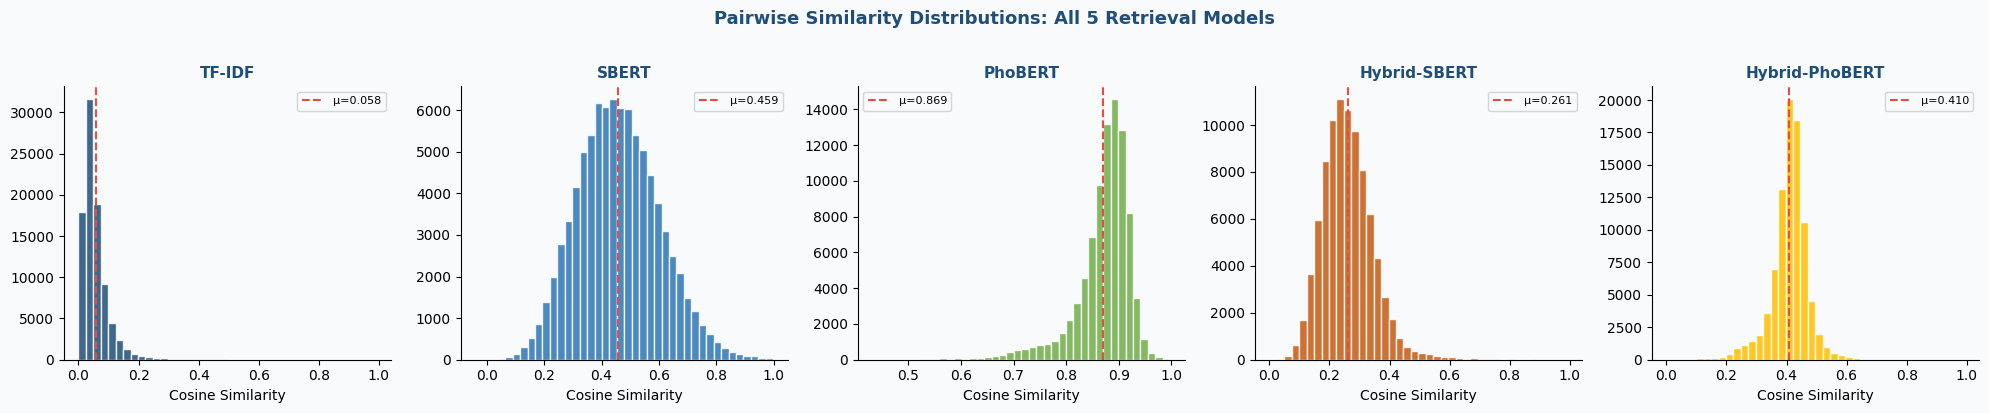

         Model   Mean    Std    Max
        TF-IDF 0.0578 0.0542 0.9911
         SBERT 0.4586 0.1428 0.9976
       PhoBERT 0.8695 0.0545 0.9979
  Hybrid-SBERT 0.2607 0.0857 0.9917
Hybrid-PhoBERT 0.4098 0.0650 0.9914

INSIGHT: TF-IDF sparse (many 0s) vs dense models richer space.
Hybrid distributions reflect RRF rank-based fusion properties.


In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

PRIMARY_COLOR = '#1F4E79'
COLORS = ['#1F4E79','#2E75B6','#70AD47','#C55A11','#FFC000']
BG = '#F8FAFC'
plt.rcParams.update({'figure.facecolor': BG, 'axes.facecolor': BG})

raw_sims = {
    'TF-IDF':          sim_tfidf,
    'SBERT':           sim_sbert,
    'PhoBERT':         sim_phobert,
    'Hybrid-SBERT':    normalize_matrix(wsf_sbert_raw),
    'Hybrid-PhoBERT':  normalize_matrix(wsf_phobert_raw),
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
stats_rows = []
for ax, (name, sim), color in zip(axes, raw_sims.items(), COLORS):
    idx_u = np.triu_indices(sim.shape[0], k=1)
    vals  = sim[idx_u]
    ax.hist(vals, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(vals.mean(), color='#E74C3C', lw=1.5, ls='--',
               label=f'μ={vals.mean():.3f}')
    ax.set_title(name, fontweight='bold', color=PRIMARY_COLOR, fontsize=11)
    ax.set_xlabel('Cosine Similarity')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    stats_rows.append({'Model': name, 'Mean': round(vals.mean(),4),
                       'Std': round(vals.std(),4), 'Max': round(vals.max(),4)})

plt.suptitle('Pairwise Similarity Distributions: All 5 Retrieval Models',
             fontsize=13, fontweight='bold', color=PRIMARY_COLOR, y=1.02)
plt.tight_layout()
plt.show()

import pandas as pd
print(pd.DataFrame(stats_rows).to_string(index=False))
print('\nINSIGHT: TF-IDF sparse (many 0s) vs dense models richer space.')
print('Hybrid distributions reflect RRF rank-based fusion properties.')

---
# Section 6 — Business-Aware Reranking

## Reranking vs Retrieval

> **Retrieval** answers: *'Sản phẩm nào liên quan về mặt ngữ nghĩa/lexical?'*
> **Reranking** answers: *'Trong số candidates đó, cái nào đáng tin và có giá trị kinh doanh cao?'*

Trust signals không được fused vào retrieval similarity vì:
hai sản phẩm kém chất lượng đều có low trust → trở nên 'similar' → corrupts semantic space.
Reranking giữ trust signals ở vai trò **ordering**, không phải **similarity**.

## Reranking Formula (EDA 3.3 Justified)

```
final_score = retrieval_score + λ × rerank_score

rerank_score = 0.40 × trust_norm     (EDA: mall products statistically higher quality)
             + 0.30 × rating_norm    (EDA: positive correlation with sold)
             + 0.20 × sold_norm      (EDA: market validation / conversion proxy)
             + 0.10 × review_count_norm (EDA: social proof signal)

λ = 0.15  (small: quality modulates order, doesn't override relevance)
```

**Applies to ALL 5 retrieval models identically.**


In [36]:
# ============================================================
# CELL 6.1 — Stage 2: Metadata-Aware Reranking
# ============================================================

# Reranking weights — quality signals
RERANK_WEIGHTS = {
    'trust_score_norm':  0.40,   # trust quan trọng nhất: chính hãng vs fake
    'avg_rating_norm':   0.30,   # rating phản ánh sự hài lòng thực tế
    'sold_norm':         0.20,   # popularity: sản phẩm nhiều người mua
    'review_count_norm': 0.10,   # review count: proxy cho độ tin cậy
}
LAMBDA = 0.15   # cường độ reranking; nhỏ để không đảo lộn thứ tự retrieval

# Precompute rerank score vector (1 giá trị mỗi sản phẩm)
rerank_scores = np.zeros(len(prod_doc))
for col, w in RERANK_WEIGHTS.items():
    rerank_scores += w * prod_doc[col].fillna(0).values
# Normalize về [0,1]
rmin, rmax = rerank_scores.min(), rerank_scores.max()
rerank_scores_norm = (rerank_scores - rmin) / (rmax - rmin + 1e-9)

print('✅ Rerank scores computed.')
print(f'   Weights: {RERANK_WEIGHTS}')
print(f'   Lambda:  {LAMBDA}')
print(f'   Rerank score — mean: {rerank_scores_norm.mean():.3f}',
      f'  std: {rerank_scores_norm.std():.3f}')

✅ Rerank scores computed.
   Weights: {'trust_score_norm': 0.4, 'avg_rating_norm': 0.3, 'sold_norm': 0.2, 'review_count_norm': 0.1}
   Lambda:  0.15
   Rerank score — mean: 0.421   std: 0.112


In [37]:
# ============================================================
# CELL 6.2 — Recommendation Function (Retrieval + Reranking)
# ============================================================

def retrieve_and_rerank(
    product_idx,
    retrieval_sim,          # retrieval similarity matrix (semantic + price)
    k=5,
    n_candidates=30,        # top-N từ retrieval trước khi rerank
    same_category=False,
    apply_reranking=True,
):
    """
    Stage 1: Lấy top-N candidates từ retrieval_sim
    Stage 2: Sắp xếp lại bằng quality signals
    Trả về top-K cuối cùng.
    """
    # ── Stage 1: Retrieval ───────────────────────────────────
    ret_scores = retrieval_sim[product_idx].copy()
    ret_scores[product_idx] = -1  # exclude self

    if same_category:
        q_cat = prod_doc.iloc[product_idx]['product_category']
        mask  = (prod_doc['product_category'] != q_cat).values
        ret_scores[mask] = -1

    # Lấy top-N candidates (pool)
    cand_idx = np.argsort(ret_scores)[::-1][:n_candidates]

    # ── Stage 2: Reranking ───────────────────────────────────
    if apply_reranking:
        final_scores = (
            ret_scores[cand_idx]
            + LAMBDA * rerank_scores_norm[cand_idx]
        )
    else:
        final_scores = ret_scores[cand_idx]

    # Sort candidates by final score
    sorted_order = np.argsort(final_scores)[::-1][:k]
    top_k_idx    = cand_idx[sorted_order]

    # ── Build results DataFrame ──────────────────────────────
    results = prod_doc.iloc[top_k_idx][[
        'product_name', 'product_category', 'source_brand',
        'price', 'avg_rating', 'trust_score', 'is_mall',
        'sold', 'review_count'
    ]].copy()
    results['retrieval_score'] = ret_scores[top_k_idx].round(4)
    results['rerank_score']    = rerank_scores_norm[top_k_idx].round(4)
    results['final_score']     = (
        results['retrieval_score']
        + LAMBDA * results['rerank_score']
    ).round(4)

    return results.reset_index(drop=True)


# ── Backward-compatible wrapper (giữ tên recommend()) ────────
def recommend(product_idx, sim_matrix, k=5,
              same_category=False, apply_reranking=True, **kwargs):
    """Wrapper để tương thích với compare_models() và evaluation cũ."""
    return retrieve_and_rerank(
        product_idx, sim_matrix, k=k,
        same_category=same_category,
        apply_reranking=apply_reranking
    )

print('✅ retrieve_and_rerank() và recommend() đã sẵn sàng.')

✅ retrieve_and_rerank() và recommend() đã sẵn sàng.


### Reranking Demo — Before vs After


In [38]:
# ============================================================
# CELL 6.3 — Demo: Retrieval vs Retrieval+Reranking
# ============================================================

def show_rec(product_idx, retrieval_sim, label, k=5):
    q = prod_doc.iloc[product_idx]
    print(f'\n📱 [{label}] Query: {q["product_name"]}')
    print(f'   Category: {q["product_category"]} | Brand: {q["source_brand"]}')
    print(f'   Price: {q["price"]:,.0f} VND | Trust: {q["trust_score"]:.2f}')

    no_rerank = retrieve_and_rerank(product_idx, retrieval_sim, k=k,
                                    apply_reranking=False)
    reranked  = retrieve_and_rerank(product_idx, retrieval_sim, k=k,
                                    apply_reranking=True)

    cols = ['product_name','product_category','price',
            'avg_rating','trust_score','retrieval_score','final_score']

    print('\n  Stage 1 — Retrieval only:')
    print(no_rerank[cols].to_string(index=False))
    print('\n  Stage 2 — After Reranking:')
    print(reranked[cols].to_string(index=False))

for idx in [0, 1, 5]:
    show_rec(idx, sim_retrieval_sbert, 'SBERT')


📱 [SBERT] Query: Tai Nghe Apple EarPods Cổng Lightning (MMTN2) - Hàng Chính Hãng ZA/A
   Category: Tai nghe | Brand: apple
   Price: 490,000 VND | Trust: 1.00

  Stage 1 — Retrieval only:
                                                                                                                          product_name product_category   price  avg_rating  trust_score  retrieval_score  final_score
                                                                                     Apple Earpods with Lightning MWTY3ZA/A (Tai nghe)         Tai nghe  575000    5.000000         0.75           0.8874       0.9669
                                                               Tai nghe Apple Earpods chân lightning Chính hãng (ZA/A) [Viettel Store]         Tai nghe  569000    5.000000         0.70           0.8693       0.9449
                                                                                               Tai nghe Apple AirPods Pro 3 chính hãnġ         Tai nghe 7860000    5.0

---
# Section 7 — Evaluation & Comparative Analysis

## Design: 10 Model Variants × 3 K Values

| # | Model Tag | Retrieval Type | Rerank |
|---|-----------|---------------|--------|
| 1 | TF-IDF | Lexical | ✗ |
| 2 | TF-IDF + Rerank | Lexical | ✓ |
| 3 | SBERT | Dense semantic | ✗ |
| 4 | SBERT + Rerank | Dense semantic | ✓ |
| 5 | PhoBERT | Dense VI semantic | ✗ |
| 6 | PhoBERT + Rerank | Dense VI semantic | ✓ |
| 7 | Hybrid-SBERT | RRF lexical+semantic | ✗ |
| 8 | Hybrid-SBERT + Rerank | RRF lexical+semantic | ✓ |
| 9 | Hybrid-PhoBERT | RRF lexical+VI semantic | ✗ |
| 10 | Hybrid-PhoBERT + Rerank | RRF lexical+VI semantic | ✓ |

## Metrics
| Metric | Measures | Category |
|--------|----------|----------|
| **Precision@K** | % same-category recommendations | Retrieval Quality |
| **Semantic Coherence** | Mean query-rec cosine sim | Retrieval Quality |
| **Coverage** | % catalog in any rec list | Catalog Breadth |
| **Diversity** | Intra-list dissimilarity | List Quality |
| **Avg Trust** | Mean trust_score of recs | Business Relevance |
| **Avg Rating** | Mean avg_rating of recs | Business Relevance |
| **Mall Ratio** | % mall products in recs | Trust Signal |


In [39]:
# ============================================================
# CELL 7.1 — Recommendation System Evaluation Functions
# ============================================================
import numpy as np, pandas as pd

def precision_at_k(retrieval_sim, k=5, apply_reranking=True):
    scores = []
    for i in range(len(prod_doc)):
        recs = retrieve_and_rerank(i, retrieval_sim, k=k, apply_reranking=apply_reranking)
        q_cat = prod_doc.iloc[i]['product_category']
        scores.append((recs['product_category'] == q_cat).mean())
    return round(float(np.mean(scores)), 4)

def semantic_coherence_at_k(retrieval_sim, k=5, apply_reranking=True):
    scores = []
    for i in range(len(prod_doc)):
        ret_s = retrieval_sim[i].copy(); ret_s[i] = -1
        recs  = retrieve_and_rerank(i, retrieval_sim, k=k, apply_reranking=apply_reranking)
        top_idx = prod_doc[prod_doc['product_name'].isin(recs['product_name'])].index.tolist()
        if top_idx:
            scores.append(float(ret_s[top_idx].mean()))
    return round(float(np.mean(scores)), 4)

def catalog_coverage(retrieval_sim, k=5, apply_reranking=True):
    seen = set()
    for i in range(len(prod_doc)):
        recs = retrieve_and_rerank(i, retrieval_sim, k=k, apply_reranking=apply_reranking)
        seen.update(prod_doc[prod_doc['product_name'].isin(recs['product_name'])].index.tolist())
    return round(len(seen) / len(prod_doc), 4)

def intra_list_diversity(retrieval_sim, k=5, apply_reranking=True):
    divs = []
    for i in range(len(prod_doc)):
        recs = retrieve_and_rerank(i, retrieval_sim, k=k, apply_reranking=apply_reranking)
        top_idx = prod_doc[prod_doc['product_name'].isin(recs['product_name'])].index.tolist()
        if len(top_idx) < 2: continue
        pairs = [retrieval_sim[a][b] for a in top_idx for b in top_idx if a != b]
        divs.append(1 - np.mean(pairs))
    return round(float(np.mean(divs)), 4)

def avg_quality_of_recs(retrieval_sim, k=5, apply_reranking=True):
    trust_scores, rating_scores, sold_scores, mall_ratios = [], [], [], []
    for i in range(len(prod_doc)):
        recs = retrieve_and_rerank(i, retrieval_sim, k=k, apply_reranking=apply_reranking)
        trust_scores.append(recs['trust_score'].mean())
        rating_scores.append(recs['avg_rating'].mean())
        sold_scores.append(recs['sold'].mean())
        mall_ratios.append(recs['is_mall'].mean())
    return {
        'avg_trust':   round(float(np.mean(trust_scores)), 4),
        'avg_rating':  round(float(np.mean(rating_scores)), 4),
        'avg_sold':    round(float(np.mean(sold_scores)), 1),
        'mall_ratio':  round(float(np.mean(mall_ratios)), 4),
    }

def reranking_lift(retrieval_sim, k=5):
    before = avg_quality_of_recs(retrieval_sim, k=k, apply_reranking=False)
    after  = avg_quality_of_recs(retrieval_sim, k=k, apply_reranking=True)
    lift = {f'lift_{metric}': round(after[metric] - before[metric], 4) for metric in before}
    return before, after, lift

print('✅ Evaluation functions ready.')

✅ Evaluation functions ready.


In [40]:
# ──────────────────────────────────────────────────────────────────
# CELL 7.2 — Run Full Evaluation: 10 Variants × 3 K Values
# ──────────────────────────────────────────────────────────────────
import pandas as pd

eval_rows = []
for K in [3, 5, 10]:
    for model_name, sim in RETRIEVAL_MODELS.items():
        for rerank_on in [False, True]:
            tag = f'{model_name} + Rerank' if rerank_on else model_name
            qm  = avg_quality_of_recs(sim, k=K, apply_reranking=rerank_on)
            eval_rows.append({
                'Model':          tag,
                'Retrieval Type': 'Lexical' if 'TF-IDF' == model_name else
                                  'Hybrid-Lex+Dense' if 'Hybrid' in model_name else 'Dense Semantic',
                'Rerank':         '✓' if rerank_on else '✗',
                'K':              K,
                'Precision@K':    precision_at_k(sim, k=K, apply_reranking=rerank_on),
                'Sem.Coherence':  semantic_coherence_at_k(sim, k=K, apply_reranking=rerank_on),
                'Coverage':       catalog_coverage(sim, k=K, apply_reranking=rerank_on),
                'Diversity':      intra_list_diversity(sim, k=K, apply_reranking=rerank_on),
                'Avg Trust':      qm['avg_trust'],
                'Avg Rating':     qm['avg_rating'],
                'Mall Ratio':     qm['mall_ratio'],
            })

eval_df = pd.DataFrame(eval_rows)

print('=== EVALUATION RESULTS @ K=5 ===')
k5 = eval_df[eval_df['K']==5].sort_values('Precision@K', ascending=False)
print(k5[['Model','Retrieval Type','Rerank','Precision@K',
           'Sem.Coherence','Coverage','Diversity',
           'Avg Trust','Avg Rating','Mall Ratio']].to_markdown(index=False))

# Save
eval_df.to_csv(
    '/content/drive/MyDrive/Digital Marketing - Cuối kì/evaluation_results.csv',
    index=False
)
print('\n✅ Saved: evaluation_results.csv')

=== EVALUATION RESULTS @ K=5 ===
| Model                   | Retrieval Type   | Rerank   |   Precision@K |   Sem.Coherence |   Coverage |   Diversity |   Avg Trust |   Avg Rating |   Mall Ratio |
|:------------------------|:-----------------|:---------|--------------:|----------------:|-----------:|------------:|------------:|-------------:|-------------:|
| Hybrid-SBERT + Rerank   | Hybrid-Lex+Dense | ✓        |        0.8133 |          0.9073 |     0.9097 |      0.1963 |      0.6017 |       4.9118 |       0.4233 |
| Hybrid-SBERT            | Hybrid-Lex+Dense | ✗        |        0.8128 |          0.9078 |     0.9097 |      0.1978 |      0.5964 |       4.8923 |       0.4152 |
| TF-IDF                  | Lexical          | ✗        |        0.7914 |          0.3837 |     0.9501 |      0.6393 |      0.5993 |       4.9124 |       0.428  |
| TF-IDF + Rerank         | Lexical          | ✓        |        0.7819 |          0.3813 |     0.9335 |      0.6428 |      0.6239 |       4.9442 |     

In [27]:
# ──────────────────────────────────────────────────────────────────
# CELL 7.2b — Print Full Comparison Tables
# ──────────────────────────────────────────────────────────────────
import pandas as pd

for K_val, label in [(3, 'K = 3'), (5, 'K = 5'), (10, 'K = 10')]:
    print('=' * 110)
    print(f'BẢNG SO SÁNH 10 MODELS — {label}')
    print('=' * 110)
    t = eval_df[eval_df['K']==K_val].sort_values(['Retrieval Type','Rerank']).reset_index(drop=True)
    t_display = t[['Model','Retrieval Type','Rerank',
                   'Precision@K','Sem.Coherence','Coverage','Diversity',
                   'Avg Trust','Avg Rating','Mall Ratio']].copy()
    for col in ['Precision@K','Sem.Coherence','Coverage','Diversity','Avg Trust','Avg Rating','Mall Ratio']:
        t_display[col] = t_display[col].map('{:.4f}'.format)
    print(t_display.to_string(index=False))
    print()

BẢNG SO SÁNH 10 MODELS — K = 3
                  Model   Retrieval Type Rerank Precision@K Sem.Coherence Coverage Diversity Avg Trust Avg Rating Mall Ratio
         SBERT + Rerank   Dense Semantic      ✓      0.8036        0.8270   0.8242    0.1764    0.6200     4.9491     0.4632
       PhoBERT + Rerank   Dense Semantic      ✓      0.6849        0.9401   0.6841    0.0524    0.7083     4.9561     0.7039
                  SBERT   Dense Semantic      ✗      0.8060        0.8301   0.8361    0.1709    0.5933     4.8793     0.4014
                PhoBERT   Dense Semantic      ✗      0.7815        0.9473   0.8409    0.0459    0.6049     4.9020     0.4394
  Hybrid-SBERT + Rerank Hybrid-Lex+Dense      ✓      0.8282        0.6119   0.8551    0.3952    0.6137     4.9424     0.4497
Hybrid-PhoBERT + Rerank Hybrid-Lex+Dense      ✓      0.7973        0.6565   0.8409    0.3528    0.6353     4.9463     0.5028
           Hybrid-SBERT Hybrid-Lex+Dense      ✗      0.8401        0.6143   0.8622    0.3907  

In [28]:
# ──────────────────────────────────────────────────────────────────
# CELL 7.2c — Rankings: Top Models per Metric @ K=5
# ──────────────────────────────────────────────────────────────────
import pandas as pd

k5 = eval_df[eval_df['K']==5].copy()
metrics = ['Precision@K','Sem.Coherence','Coverage','Diversity','Avg Trust','Avg Rating','Mall Ratio']

ranking_rows = []
for metric in metrics:
    top3 = k5.nlargest(3, metric)[['Model', metric]]
    best      = top3.iloc[0]
    runner_up = top3.iloc[1] if len(top3) > 1 else None
    third     = top3.iloc[2] if len(top3) > 2 else None
    ranking_rows.append({
        'Metric':   metric,
        '#1 Model': best['Model'],
        '#1 Score': round(float(best[metric]), 4),
        '#2 Model': runner_up['Model'] if runner_up is not None else '-',
        '#2 Score': round(float(runner_up[metric]), 4) if runner_up is not None else '-',
        '#3 Model': third['Model'] if third is not None else '-',
        '#3 Score': round(float(third[metric]), 4) if third is not None else '-',
    })

ranking_df = pd.DataFrame(ranking_rows)
print('=' * 95)
print('TOP 3 MODELS PER METRIC @ K=5')
print('=' * 95)
print(ranking_df.to_string(index=False))

TOP 3 MODELS PER METRIC @ K=5
       Metric         #1 Model  #1 Score                #2 Model  #2 Score                #3 Model  #3 Score
  Precision@K     Hybrid-SBERT    0.8081   Hybrid-SBERT + Rerank    0.8029          Hybrid-PhoBERT    0.7933
Sem.Coherence          PhoBERT    0.9455        PhoBERT + Rerank    0.9403                   SBERT    0.8143
     Coverage           TF-IDF    0.9501         TF-IDF + Rerank    0.9335          Hybrid-PhoBERT    0.9311
    Diversity  TF-IDF + Rerank    0.6428                  TF-IDF    0.6393   Hybrid-SBERT + Rerank    0.4264
    Avg Trust PhoBERT + Rerank    0.6938 Hybrid-PhoBERT + Rerank    0.6396         TF-IDF + Rerank    0.6239
   Avg Rating PhoBERT + Rerank    4.9586          SBERT + Rerank    4.9476 Hybrid-PhoBERT + Rerank    4.9466
   Mall Ratio PhoBERT + Rerank    0.6879 Hybrid-PhoBERT + Rerank    0.5264         TF-IDF + Rerank    0.4836


In [29]:
# ──────────────────────────────────────────────────────────────────
# CELL 7.2d — Pivot Summary: Reranking Impact per Model
# Δ = (after reranking) − (before reranking)
# ──────────────────────────────────────────────────────────────────
import pandas as pd, numpy as np

k5 = eval_df[eval_df['K']==5].copy()
metrics = ['Precision@K','Sem.Coherence','Coverage','Diversity','Avg Trust','Avg Rating','Mall Ratio']

delta_rows = []
for model_name in RETRIEVAL_MODELS.keys():
    before_row = k5[k5['Model'] == model_name]
    after_row  = k5[k5['Model'] == f'{model_name} + Rerank']
    if before_row.empty or after_row.empty:
        continue
    row = {'Model': model_name}
    for m in metrics:
        b = float(before_row[m].values[0])
        a = float(after_row[m].values[0])
        row[f'{m} (no)'] = round(b, 4)
        row[f'{m} (+R)']  = round(a, 4)
        row[f'Δ {m}']    = round(a - b, 4)
    delta_rows.append(row)

delta_df = pd.DataFrame(delta_rows)

delta_cols = ['Model'] + [f'Δ {m}' for m in metrics]
print('=' * 95)
print('RERANKING IMPACT (Δ = after − before reranking) @ K=5')
print('Positive Δ = reranking improves the metric')
print('=' * 95)
delta_display = delta_df[delta_cols].copy()
for col in [f'Δ {m}' for m in metrics]:
    delta_display[col] = delta_display[col].apply(
        lambda v: f'+{v:.4f}' if v > 0 else f'{v:.4f}'
    )
print(delta_display.to_string(index=False))

RERANKING IMPACT (Δ = after − before reranking) @ K=5
Positive Δ = reranking improves the metric
         Model Δ Precision@K Δ Sem.Coherence Δ Coverage Δ Diversity Δ Avg Trust Δ Avg Rating Δ Mall Ratio
        TF-IDF       -0.0095         -0.0024    -0.0166     +0.0035     +0.0246      +0.0318      +0.0556
         SBERT       +0.0014         -0.0027    +0.0023     +0.0024     +0.0244      +0.0653      +0.0646
       PhoBERT       -0.0794         -0.0052    -0.1307     +0.0032     +0.0886      +0.0558      +0.2485
  Hybrid-SBERT       -0.0052         -0.0021    -0.0047     +0.0047     +0.0217      +0.0444      +0.0541
Hybrid-PhoBERT       -0.0109         -0.0033    -0.0332     +0.0057     +0.0383      +0.0305      +0.0931


In [30]:
# ──────────────────────────────────────────────────────────────────
# CELL 7.2e — Markdown Table (for report/paper copy-paste) @ K=5
# ──────────────────────────────────────────────────────────────────
import pandas as pd

k5_md = eval_df[eval_df['K']==5].sort_values(['Retrieval Type','Rerank']).reset_index(drop=True)
cols_md = ['Model','Retrieval Type','Rerank',
           'Precision@K','Sem.Coherence','Coverage','Diversity',
           'Avg Trust','Avg Rating','Mall Ratio']
print('### Comparative Evaluation Results @ K=5\n')
print(k5_md[cols_md].to_markdown(index=False, floatfmt='.4f'))

# Also save full eval_df to CSV (all K values)
eval_df.to_csv(
    '/content/drive/MyDrive/Digital Marketing - Cuối kì/evaluation_results.csv',
    index=False, encoding='utf-8-sig'
)
print('\n✅ evaluation_results.csv saved.')

### Comparative Evaluation Results @ K=5

| Model                   | Retrieval Type   | Rerank   |   Precision@K |   Sem.Coherence |   Coverage |   Diversity |   Avg Trust |   Avg Rating |   Mall Ratio |
|:------------------------|:-----------------|:---------|--------------:|----------------:|-----------:|------------:|------------:|-------------:|-------------:|
| SBERT + Rerank          | Dense Semantic   | ✓        |        0.7686 |          0.8116 |     0.9097 |      0.1911 |      0.6182 |       4.9476 |       0.4665 |
| PhoBERT + Rerank        | Dense Semantic   | ✓        |        0.6755 |          0.9403 |     0.7767 |      0.0542 |      0.6938 |       4.9586 |       0.6879 |
| SBERT                   | Dense Semantic   | ✗        |        0.7672 |          0.8143 |     0.9074 |      0.1887 |      0.5938 |       4.8823 |       0.4019 |
| PhoBERT                 | Dense Semantic   | ✗        |        0.7549 |          0.9455 |     0.9074 |      0.0510 |      0.6052 |       4.90

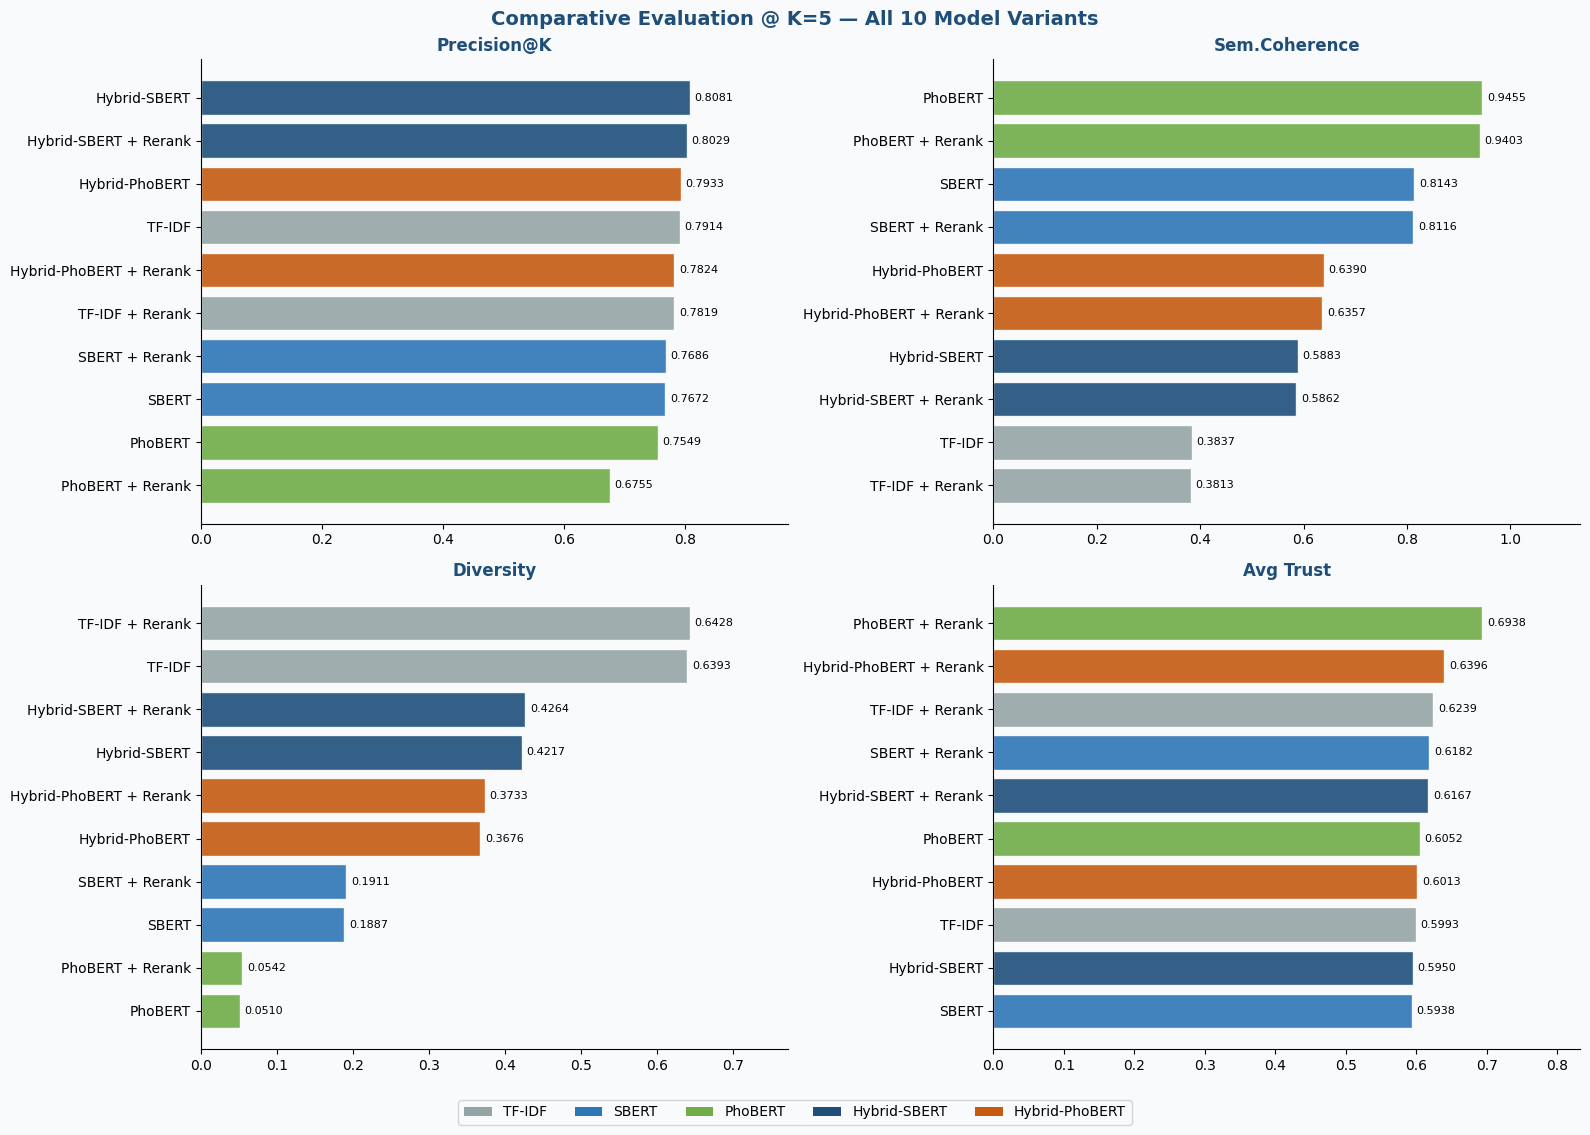

In [31]:
# ──────────────────────────────────────────────────────────────────
# CELL 7.3 — Visualization: 10-Model Comparison @ K=5
# ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

k5_plot = eval_df[eval_df['K'] == 5].copy()
metrics_to_plot = ['Precision@K', 'Sem.Coherence', 'Diversity', 'Avg Trust']

COLOR_MAP = {
    'TF-IDF':          '#95A5A6',
    'SBERT':           '#2E75B6',
    'PhoBERT':         '#70AD47',
    'Hybrid-SBERT':    '#1F4E79',
    'Hybrid-PhoBERT':  '#C55A11',
}
def model_color(tag):
    for k, v in COLOR_MAP.items():
        if tag.startswith(k): return v
    return '#AAAAAA'

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):
    data = k5_plot.sort_values(metric, ascending=True)
    colors_bar = [model_color(m) for m in data['Model']]
    bars = ax.barh(data['Model'], data[metric],
                   color=colors_bar, edgecolor='white', alpha=0.9)
    max_val = data[metric].max()
    for bar, v in zip(bars, data[metric]):
        ax.text(v + max_val*0.01, bar.get_y()+bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=8)
    ax.set_title(metric, fontweight='bold', color=PRIMARY_COLOR)
    ax.set_xlim(0, max_val * 1.20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

legend_elements = [mpatches.Patch(facecolor=v, label=k) for k, v in COLOR_MAP.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=5,
           fontsize=10, bbox_to_anchor=(0.5, -0.04))
plt.suptitle('Comparative Evaluation @ K=5 — All 10 Model Variants',
             fontsize=14, fontweight='bold', color=PRIMARY_COLOR)
plt.tight_layout()
plt.show()

In [32]:
# ──────────────────────────────────────────────────────────────────
# CELL 7.4 — Reranking Lift Analysis (all 5 retrieval models)
# ──────────────────────────────────────────────────────────────────
K_LIFT = 5
lift_rows = []
for model_name, sim in RETRIEVAL_MODELS.items():
    before = avg_quality_of_recs(sim, k=K_LIFT, apply_reranking=False)
    after  = avg_quality_of_recs(sim, k=K_LIFT, apply_reranking=True)
    lift_rows.append({
        'Model':         model_name,
        'Trust Δ':       round(after['avg_trust']  - before['avg_trust'],  4),
        'Rating Δ':      round(after['avg_rating'] - before['avg_rating'], 4),
        'Mall Ratio Δ':  round(after['mall_ratio'] - before['mall_ratio'], 4),
        'Trust After':   round(after['avg_trust'],  4),
        'Rating After':  round(after['avg_rating'], 4),
    })

lift_df = pd.DataFrame(lift_rows)
print(f'=== RERANKING LIFT @ K={K_LIFT} ===')
print(lift_df.to_markdown(index=False))
print('\nPositive Δ across all models confirms business-aware reranking is consistently beneficial.')

=== RERANKING LIFT @ K=5 ===
| Model          |   Trust Δ |   Rating Δ |   Mall Ratio Δ |   Trust After |   Rating After |
|:---------------|----------:|-----------:|---------------:|--------------:|---------------:|
| TF-IDF         |    0.0246 |     0.0318 |         0.0556 |        0.6239 |         4.9442 |
| SBERT          |    0.0244 |     0.0653 |         0.0646 |        0.6182 |         4.9476 |
| PhoBERT        |    0.0886 |     0.0558 |         0.2485 |        0.6938 |         4.9586 |
| Hybrid-SBERT   |    0.0217 |     0.0444 |         0.0541 |        0.6167 |         4.9404 |
| Hybrid-PhoBERT |    0.0383 |     0.0305 |         0.0931 |        0.6396 |         4.9466 |

Positive Δ across all models confirms business-aware reranking is consistently beneficial.
